In [1]:
# ============================================================
# CTU-13 C2 DATASET EXPLORATION
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

C2_FILE = Path(
    "../data/raw/CTU-13/capture20110810.binetflow"
)

print("File exists:", C2_FILE.exists())

if C2_FILE.exists():
    print(
        "File size (MB):",
        round(C2_FILE.stat().st_size / (1024 ** 2), 2)
    )

File exists: True
File size (MB): 368.72


In [2]:
# ============================================================
# READ SMALL SAMPLE
# ============================================================

c2_sample = pd.read_csv(
    C2_FILE,
    nrows=5000
)

print("Sample shape:", c2_sample.shape)

print("\nColumns:")
for i, col in enumerate(c2_sample.columns, start=1):
    print(f"{i:02d}. {col}")

print("\nFirst 5 rows:")
display(c2_sample.head())

Sample shape: (5000, 15)

Columns:
01. StartTime
02. Dur
03. Proto
04. SrcAddr
05. Sport
06. Dir
07. DstAddr
08. Dport
09. State
10. sTos
11. dTos
12. TotPkts
13. TotBytes
14. SrcBytes
15. Label

First 5 rows:


,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011/08/10 09:46:53.047277,3550.182373,udp,212.50.71.179,39678,<->,147.32.84.229,13363,CON,0.0,0.0,12,875,413,flow=Background-UDP-Established
1,2011/08/10 09:46:53.048843,0.000883,udp,84.13.246.132,28431,<->,147.32.84.229,13363,CON,0.0,0.0,2,135,75,flow=Background-UDP-Established
2,2011/08/10 09:46:53.049895,0.000326,tcp,217.163.21.35,80,<?>,147.32.86.194,2063,FA_A,0.0,0.0,2,120,60,flow=Background
3,2011/08/10 09:46:53.053771,0.056966,tcp,83.3.77.74,32882,<?>,147.32.85.5,21857,FA_FA,0.0,0.0,3,180,120,flow=Background
4,2011/08/10 09:46:53.053937,3427.768066,udp,74.89.223.204,21278,<->,147.32.84.229,13363,CON,0.0,0.0,42,2856,1596,flow=Background-UDP-Established


In [3]:
# ============================================================
# LABEL INSPECTION
# ============================================================

if "Label" in c2_sample.columns:

    print("Label distribution:")
    display(
        c2_sample["Label"]
        .value_counts(dropna=False)
    )

else:
    print("No 'Label' column found.")

Label distribution:


Label
flow=Background-UDP-Established             2528
flow=To-Background-UDP-CVUT-DNS-Server       920
flow=Background                              614
flow=Background-Established-cmpgw-CVUT       243
flow=Background-TCP-Established              235
flow=Background-UDP-Attempt                  170
flow=Background-Attempt-cmpgw-CVUT            74
flow=Background-UDP-NTP-Established-1         33
flow=Background-google-analytics3             24
flow=From-Normal-V42-Jist                     24
flow=Background-TCP-Attempt                   17
flow=To-Background-CVUT-WebServer             14
flow=From-Background-CVUT-Proxy               14
flow=From-Normal-V42-Stribrek                 12
flow=To-Background-CVUT-Proxy                 12
flow=Background-google-analytics14             8
flow=Background-google-analytics11             6
flow=Background-google-analytics2              6
flow=Background-ajax.google                    6
flow=Background-google-analytics1              5
flow=Backgroun

In [4]:
# ============================================================
# TIMESTAMP INSPECTION
# ============================================================

if "StartTime" in c2_sample.columns:

    c2_sample["StartTime_parsed"] = pd.to_datetime(
        c2_sample["StartTime"],
        errors="coerce"
    )

    print(
        "Timestamp parsing failures:",
        c2_sample["StartTime_parsed"].isna().sum()
    )

    print(
        "First timestamp:",
        c2_sample["StartTime_parsed"].min()
    )

    print(
        "Last timestamp:",
        c2_sample["StartTime_parsed"].max()
    )

else:
    print("StartTime column not found.")

Timestamp parsing failures: 0
First timestamp: 2011-08-10 09:46:53.047277
Last timestamp: 2011-08-10 09:47:17.811784


In [5]:
# ============================================================
# FULL CTU-13 LABEL SCAN
# Read in chunks so we never load the 369 MB file at once.
# ============================================================

label_counts = {}

for chunk in pd.read_csv(
    C2_FILE,
    usecols=["Label"],
    chunksize=50_000
):
    counts = chunk["Label"].value_counts(dropna=False)

    for label, count in counts.items():
        label_counts[label] = (
            label_counts.get(label, 0) + int(count)
        )

label_counts = (
    pd.Series(label_counts)
    .sort_values(ascending=False)
)

print("Total labelled flows:")
print(label_counts.sum())

print("\nNumber of unique labels:")
print(len(label_counts))

print("\nAll labels:")
display(label_counts)

Total labelled flows:
2824636

Number of unique labels:
113

All labels:


flow=Background-UDP-Established                                            1169677
flow=To-Background-UDP-CVUT-DNS-Server                                      941706
flow=Background-TCP-Established                                             223543
flow=Background-Established-cmpgw-CVUT                                      137257
flow=Background-TCP-Attempt                                                 105438
                                                                            ...   
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-60                                  1
flow=From-Botnet-V42-TCP-HTTP-Not-Encrypted-Down-2                               1
flow=From-Botnet-V42-TCP-Established-HTTP-Binary-Download-Custom-Port-5          1
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-49                                  1
flow=From-Botnet-V42-TCP-Established-HTTP-Adobe-4                                1
Length: 113, dtype: int64

In [6]:
# ============================================================
# FIND BOTNET / C&C RELATED LABELS
# ============================================================

label_text = label_counts.index.astype(str)

interesting_labels = label_counts[
    label_text.str.contains(
        "botnet|c&c|c2|command|control",
        case=False,
        regex=True
    )
]

print("Potential Botnet/C&C labels:")
display(interesting_labels)

Potential Botnet/C&C labels:


flow=From-Botnet-V42-UDP-DNS                                               26140
flow=From-Botnet-V42-TCP-Attempt-SPAM                                       8105
flow=From-Botnet-V42-UDP-Attempt-DNS                                        3057
flow=From-Botnet-V42-TCP-Attempt                                            1881
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-63                              352
                                                                           ...  
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-60                                1
flow=From-Botnet-V42-TCP-HTTP-Not-Encrypted-Down-2                             1
flow=From-Botnet-V42-TCP-Established-HTTP-Binary-Download-Custom-Port-5        1
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-49                                1
flow=From-Botnet-V42-TCP-Established-HTTP-Adobe-4                              1
Length: 68, dtype: int64

In [7]:
# ============================================================
# LABEL PREFIX ANALYSIS
# ============================================================

def label_prefix(label):
    label = str(label)

    if "-" in label:
        return label.split("-")[0]

    return label

prefix_counts = (
    label_counts
    .groupby(
        label_counts.index.to_series()
        .map(label_prefix)
    )
    .sum()
    .sort_values(ascending=False)
)

print("Label prefixes:")
display(prefix_counts)

Label prefixes:


flow=Background    1787731
flow=To             965175
flow=From            71721
flow=Normal              9
dtype: int64

In [8]:
# ============================================================
# READ FLOW FIELDS FOR C2 ANALYSIS
# ============================================================

flow_columns = [
    "StartTime",
    "Dur",
    "Proto",
    "SrcAddr",
    "Sport",
    "Dir",
    "DstAddr",
    "Dport",
    "TotPkts",
    "TotBytes",
    "SrcBytes",
    "Label"
]

analysis_chunks = []

for chunk in pd.read_csv(
    C2_FILE,
    usecols=flow_columns,
    chunksize=100_000
):
    analysis_chunks.append(chunk)

c2_df = pd.concat(
    analysis_chunks,
    ignore_index=True
)

print("Loaded C2 analysis dataframe:")
print(c2_df.shape)

Loaded C2 analysis dataframe:
(2824636, 12)


In [9]:
# ============================================================
# PREPARE TEMPORAL FLOW DATA
# ============================================================

c2_df["StartTime"] = pd.to_datetime(
    c2_df["StartTime"],
    errors="coerce"
)

c2_df = c2_df.dropna(
    subset=["StartTime", "SrcAddr", "DstAddr"]
)

c2_df = c2_df.sort_values(
    "StartTime"
).reset_index(drop=True)

print("Rows after timestamp/source/destination cleaning:")
print(len(c2_df))

print(
    "Time range:",
    c2_df["StartTime"].min(),
    "→",
    c2_df["StartTime"].max()
)

Rows after timestamp/source/destination cleaning:
2824636
Time range: 2011-08-10 09:46:53.047277 → 2011-08-10 15:54:07.368340


In [10]:
# ============================================================
# BOTNET DIRECTION LABEL ANALYSIS
# ============================================================

botnet_labels = label_counts[
    label_counts.index.astype(str).str.contains(
        "Botnet-V42",
        case=False,
        regex=False
    )
]

print("Botnet-related labels:")
display(botnet_labels)

print("\nTotal Botnet-labelled flows:")
print(botnet_labels.sum())

Botnet-related labels:


flow=From-Botnet-V42-UDP-DNS                                               26140
flow=From-Botnet-V42-TCP-Attempt-SPAM                                       8105
flow=From-Botnet-V42-UDP-Attempt-DNS                                        3057
flow=From-Botnet-V42-TCP-Attempt                                            1881
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-63                              352
                                                                           ...  
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-60                                1
flow=From-Botnet-V42-TCP-HTTP-Not-Encrypted-Down-2                             1
flow=From-Botnet-V42-TCP-Established-HTTP-Binary-Download-Custom-Port-5        1
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-49                                1
flow=From-Botnet-V42-TCP-Established-HTTP-Adobe-4                              1
Length: 68, dtype: int64


Total Botnet-labelled flows:
40961


In [11]:
# ============================================================
# FROM / TO BOTNET ANALYSIS
# ============================================================

label_index = label_counts.index.astype(str)

from_botnet = label_counts[
    label_index.str.contains(
        "From-Botnet-V42",
        case=False,
        regex=False
    )
]

to_botnet = label_counts[
    label_index.str.contains(
        "To-Botnet-V42",
        case=False,
        regex=False
    )
]

print("FROM BOTNET:")
display(from_botnet)

print("\nTotal FROM BOTNET flows:")
print(from_botnet.sum())

print("\nTO BOTNET:")
display(to_botnet)

print("\nTotal TO BOTNET flows:")
print(to_botnet.sum())

FROM BOTNET:


flow=From-Botnet-V42-UDP-DNS                                               26140
flow=From-Botnet-V42-TCP-Attempt-SPAM                                       8105
flow=From-Botnet-V42-UDP-Attempt-DNS                                        3057
flow=From-Botnet-V42-TCP-Attempt                                            1881
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-63                              352
                                                                           ...  
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-60                                1
flow=From-Botnet-V42-TCP-HTTP-Not-Encrypted-Down-2                             1
flow=From-Botnet-V42-TCP-Established-HTTP-Binary-Download-Custom-Port-5        1
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-49                                1
flow=From-Botnet-V42-TCP-Established-HTTP-Adobe-4                              1
Length: 68, dtype: int64


Total FROM BOTNET flows:
40961

TO BOTNET:


Series([], dtype: int64)


Total TO BOTNET flows:
0


In [12]:
# ============================================================
# POSSIBLE C2-RELATED LABELS
# ============================================================

c2_keywords = [
    "C&C",
    "C2",
    "Command",
    "Control",
    "IRC",
    "HTTP"
]

possible_c2 = label_counts[
    label_counts.index.astype(str).str.contains(
        "|".join(c2_keywords),
        case=False,
        regex=True
    )
]

print("Labels containing C2-related keywords:")
display(possible_c2)

Labels containing C2-related keywords:


flow=From-Botnet-V42-TCP-Established-HTTP-Ad-63                            352
flow=From-Botnet-V42-TCP-CC16-HTTP-Not-Encrypted                           221
flow=From-Botnet-V42-TCP-CC53-HTTP-Not-Encrypted                            53
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-1                              38
flow=From-Botnet-V42-TCP-CC1-HTTP-Not-Encrypted                             37
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-20                             32
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-18                             31
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-21                             31
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-15                             29
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-55                             28
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-yieldmanager-9                 26
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-44                             23
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-37     

In [13]:
# ============================================================
# INSPECT BOTNET FLOWS
# ============================================================

botnet_mask = (
    c2_df["Label"]
    .astype(str)
    .str.contains(
        "Botnet-V42",
        case=False,
        regex=False
    )
)

botnet_df = c2_df[
    botnet_mask
].copy()

print("Botnet rows:", len(botnet_df))

display(
    botnet_df[
        [
            "StartTime",
            "Proto",
            "SrcAddr",
            "Sport",
            "Dir",
            "DstAddr",
            "Dport",
            "TotPkts",
            "TotBytes",
            "SrcBytes",
            "Label"
        ]
    ]
    .head(30)
)

Botnet rows: 40961


,StartTime,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,TotPkts,TotBytes,SrcBytes,Label
675537,2011-08-10 11:04:24.863449,udp,147.32.84.165,1025,<->,147.32.80.9,53,2,203,64,flow=From-Botnet-V42-UDP-DNS
675872,2011-08-10 11:04:27.118993,udp,147.32.84.165,1025,<->,147.32.80.9,53,2,590,87,flow=From-Botnet-V42-UDP-DNS
675877,2011-08-10 11:04:27.140727,tcp,147.32.84.165,1027,->,74.125.232.195,80,7,882,629,flow=From-Botnet-V42-TCP-HTTP-Google-Net-Estab...
689920,2011-08-10 11:06:23.268442,udp,147.32.84.165,1025,<->,147.32.80.9,53,2,215,71,flow=From-Botnet-V42-UDP-DNS
689955,2011-08-10 11:06:23.606888,tcp,147.32.84.165,1039,->,60.190.222.139,65520,120,7767,2690,flow=From-Botnet-V42-TCP-Established
691663,2011-08-10 11:06:36.076294,udp,147.32.84.165,1025,<->,147.32.80.9,53,2,212,77,flow=From-Botnet-V42-UDP-DNS
691742,2011-08-10 11:06:36.536447,tcp,147.32.84.165,1040,->,94.63.149.152,80,37,27990,1046,flow=From-Botnet-V42-TCP-Established-HTTP-Bina...
691879,2011-08-10 11:06:37.477233,udp,147.32.84.165,1025,<->,147.32.80.9,53,3,295,156,flow=From-Botnet-V42-UDP-DNS
692043,2011-08-10 11:06:38.849594,tcp,147.32.84.165,1041,->,60.190.223.75,2012,72,60278,1897,flow=From-Botnet-V42-TCP-Established-HTTP-Bina...
692190,2011-08-10 11:06:40.383196,udp,147.32.84.165,1025,<->,147.32.80.9,53,2,202,72,flow=From-Botnet-V42-UDP-DNS


In [14]:
# ============================================================
# BOTNET SOURCE ANALYSIS
# ============================================================

botnet_sources = (
    botnet_df["SrcAddr"]
    .value_counts()
)

print("Top Botnet source addresses:")
display(
    botnet_sources.head(20)
)

Top Botnet source addresses:


SrcAddr
147.32.84.165    40961
Name: count, dtype: int64

In [15]:
# ============================================================
# BOTNET DESTINATION ANALYSIS
# ============================================================

botnet_destinations = (
    botnet_df["DstAddr"]
    .value_counts()
)

print("Top Botnet destination addresses:")
display(
    botnet_destinations.head(20)
)

Top Botnet destination addresses:


DstAddr
147.32.80.9        7420
194.85.105.17      1160
193.232.128.6      1128
194.85.252.62      1093
193.232.142.17     1087
192.93.0.4          994
193.232.156.17      992
209.85.225.27       960
212.117.174.7       827
174.133.57.141      352
209.85.143.27       347
79.174.74.74        329
212.117.171.138     320
79.174.72.172       297
173.192.170.88      266
205.188.190.1       253
95.163.69.51        241
178.218.208.130     229
66.94.237.64        220
205.188.103.1       216
Name: count, dtype: int64

In [16]:
# ============================================================
# SOURCE → DESTINATION REPETITION
# ============================================================

pair_counts = (
    botnet_df
    .groupby(
        ["SrcAddr", "DstAddr"]
    )
    .size()
    .sort_values(
        ascending=False
    )
)

print("Most repeated Botnet communication pairs:")
display(
    pair_counts.head(30)
)

Most repeated Botnet communication pairs:


SrcAddr        DstAddr        
147.32.84.165  147.32.80.9        7420
               194.85.105.17      1160
               193.232.128.6      1128
               194.85.252.62      1093
               193.232.142.17     1087
               192.93.0.4          994
               193.232.156.17      992
               209.85.225.27       960
               212.117.174.7       827
               174.133.57.141      352
               209.85.143.27       347
               79.174.74.74        329
               212.117.171.138     320
               79.174.72.172       297
               173.192.170.88      266
               205.188.190.1       253
               95.163.69.51        241
               178.218.208.130     229
               66.94.237.64        220
               205.188.103.1       216
               195.24.65.7         211
               64.12.139.193       210
               98.139.175.224      206
               98.139.54.60        176
               64.12.90.65       

In [17]:
# ============================================================
# INSPECT BOTNET DESTINATION PORTS
# ============================================================

botnet_port_counts = (
    botnet_df
    .groupby(["Proto", "Dport"])
    .size()
    .sort_values(ascending=False)
)

print("Top Botnet destination ports:")
display(
    botnet_port_counts.head(50)
)

Top Botnet destination ports:


Proto  Dport 
udp    53        29197
tcp    25         8105
       80         1243
       6667        974
       4506        827
       65500       320
       443         119
       587          62
       3128         29
       3817         13
       4190         13
       888          10
       5296          9
       9541          6
udp    8399          5
tcp    6251          5
       65520         5
       5231          5
       41422         2
       2012          2
       81            2
       82            2
       10298         2
icmp   0x2108        1
tcp    88            1
icmp   0xc413        1
udp    9381          1
dtype: int64

In [18]:
# ============================================================
# SEARCH FOR IRC-SPECIFIC LABELS
# ============================================================

irc_labels = label_counts[
    label_counts.index.astype(str).str.contains(
        "IRC",
        case=False,
        regex=False
    )
]

print("Labels containing IRC:")
display(irc_labels)

print(
    "\nTotal flows represented by IRC-labelled entries:",
    irc_labels.sum()
)

Labels containing IRC:


Series([], dtype: int64)


Total flows represented by IRC-labelled entries: 0


In [19]:
# ============================================================
# COMMON IRC PORT CHECK
# ============================================================

irc_port_mask = (
    botnet_df["Dport"].isin(
        [6660, 6661, 6662, 6663, 6664,
         6665, 6666, 6667, 6668, 6669,
         6697]
    )
)

irc_port_df = botnet_df[
    irc_port_mask
].copy()

print(
    "Botnet flows using common IRC destination ports:",
    len(irc_port_df)
)

display(
    irc_port_df[
        [
            "StartTime",
            "Proto",
            "SrcAddr",
            "DstAddr",
            "Dport",
            "TotPkts",
            "TotBytes",
            "Label"
        ]
    ].head(30)
)

Botnet flows using common IRC destination ports: 0


,StartTime,Proto,SrcAddr,DstAddr,Dport,TotPkts,TotBytes,Label


In [20]:
# ============================================================
# CANDIDATE C2 LABELS
# ============================================================

c2_candidate_mask = (
    botnet_df["Label"]
    .astype(str)
    .str.contains(
        "IRC|C&C|C2|Command|Control",
        case=False,
        regex=True
    )
)

c2_candidate_df = botnet_df[
    c2_candidate_mask
].copy()

print(
    "Candidate C2-labelled flows:",
    len(c2_candidate_df)
)

if len(c2_candidate_df) > 0:
    display(
        c2_candidate_df["Label"]
        .value_counts()
    )
else:
    print(
        "No explicit C2/IRC label found. "
        "We will infer candidate C2 traffic from "
        "protocol/port/temporal behaviour instead."
    )

Candidate C2-labelled flows: 0
No explicit C2/IRC label found. We will infer candidate C2 traffic from protocol/port/temporal behaviour instead.


In [21]:
# ============================================================
# C2 DESTINATION ANALYSIS
# ============================================================

if len(c2_candidate_df) > 0:

    print("Candidate C2 destinations:")
    
    display(
        c2_candidate_df["DstAddr"]
        .value_counts()
        .head(20)
    )

    print("\nCandidate C2 destination ports:")
    
    display(
        c2_candidate_df["Dport"]
        .value_counts()
        .head(20)
    )

In [22]:
# ============================================================
# NORMALIZE DESTINATION PORT
# ============================================================

botnet_df["Dport_numeric"] = pd.to_numeric(
    botnet_df["Dport"].astype(str).str.strip(),
    errors="coerce"
)

print("Original Dport dtype:", botnet_df["Dport"].dtype)

print("\nNumeric Dport values recovered:",
      botnet_df["Dport_numeric"].notna().sum())

print("\nTop numeric destination ports:")

display(
    botnet_df["Dport_numeric"]
    .value_counts()
    .head(30)
)

Original Dport dtype: object

Numeric Dport values recovered: 40959

Top numeric destination ports:


Dport_numeric
53.0       29197
25.0        8105
80.0        1243
6667.0       974
4506.0       827
65500.0      320
443.0        119
587.0         62
3128.0        29
3817.0        13
4190.0        13
888.0         10
5296.0         9
9541.0         6
6251.0         5
65520.0        5
8399.0         5
5231.0         5
82.0           2
41422.0        2
81.0           2
10298.0        2
2012.0         2
88.0           1
9381.0         1
Name: count, dtype: int64

In [23]:
# ============================================================
# VERIFY IRC PORT 6667
# ============================================================

irc6667 = botnet_df[
    botnet_df["Dport_numeric"] == 6667
].copy()

print(
    "Botnet flows to TCP/UDP destination port 6667:",
    len(irc6667)
)

display(
    irc6667[
        [
            "StartTime",
            "Proto",
            "SrcAddr",
            "DstAddr",
            "Dport",
            "Dport_numeric",
            "TotPkts",
            "TotBytes",
            "SrcBytes",
            "Label"
        ]
    ].head(30)
)

Botnet flows to TCP/UDP destination port 6667: 974


,StartTime,Proto,SrcAddr,DstAddr,Dport,Dport_numeric,TotPkts,TotBytes,SrcBytes,Label
704173,2011-08-10 11:08:27.255287,tcp,147.32.84.165,143.107.171.10,6667,6667.0,3,186,186,flow=From-Botnet-V42-TCP-Attempt
704573,2011-08-10 11:08:30.258733,tcp,147.32.84.165,180.222.136.3,6667,6667.0,2,124,124,flow=From-Botnet-V42-TCP-Attempt
705559,2011-08-10 11:08:38.573928,tcp,147.32.84.165,84.111.18.150,6667,6667.0,2,124,124,flow=From-Botnet-V42-TCP-Attempt
706724,2011-08-10 11:08:48.602099,tcp,147.32.84.165,212.12.200.158,6667,6667.0,6,366,186,flow=From-Botnet-V42-TCP-Attempt
707247,2011-08-10 11:08:52.661438,tcp,147.32.84.165,221.130.69.202,6667,6667.0,6,366,186,flow=From-Botnet-V42-TCP-Attempt
707732,2011-08-10 11:08:57.688708,tcp,147.32.84.165,82.227.106.170,6667,6667.0,2,124,124,flow=From-Botnet-V42-TCP-Attempt
709165,2011-08-10 11:09:07.692938,tcp,147.32.84.165,123.194.145.64,6667,6667.0,2,124,124,flow=From-Botnet-V42-TCP-Attempt
710900,2011-08-10 11:09:17.696956,tcp,147.32.84.165,58.143.125.236,6667,6667.0,6,366,186,flow=From-Botnet-V42-TCP-Attempt
711497,2011-08-10 11:09:22.564057,tcp,147.32.84.165,200.171.4.222,6667,6667.0,10,1148,590,flow=From-Botnet-V42-TCP-CC1-HTTP-Not-Encrypted
712053,2011-08-10 11:09:26.500381,tcp,147.32.84.165,187.106.81.34,6667,6667.0,2,124,124,flow=From-Botnet-V42-TCP-Attempt


In [24]:
# ============================================================
# LABEL DISTRIBUTION FOR PORT 6667
# ============================================================

print("Labels for destination port 6667:")

display(
    irc6667["Label"]
    .value_counts()
)

Labels for destination port 6667:


Label
flow=From-Botnet-V42-TCP-Attempt                      934
flow=From-Botnet-V42-TCP-CC1-HTTP-Not-Encrypted        37
flow=From-Botnet-V42-TCP-Established                    2
flow=From-Botnet-V42-TCP-HTTP-Not-Encrypted-Down-2      1
Name: count, dtype: int64

In [25]:
# ============================================================
# IRC-PORT COMMUNICATION PAIRS
# ============================================================

irc_pairs = (
    irc6667
    .groupby(
        ["SrcAddr", "DstAddr", "Dport_numeric"]
    )
    .size()
    .sort_values(
        ascending=False
    )
)

print("Repeated port-6667 communication pairs:")

display(
    irc_pairs.head(20)
)

Repeated port-6667 communication pairs:


SrcAddr        DstAddr          Dport_numeric
147.32.84.165  222.23.80.7      6667.0           8
               117.196.25.55    6667.0           6
               117.96.96.152    6667.0           6
               221.130.69.202   6667.0           6
               78.249.161.87    6667.0           5
               61.17.216.4      6667.0           5
               61.167.116.133   6667.0           5
               178.125.252.68   6667.0           5
               58.252.109.240   6667.0           5
               183.83.68.80     6667.0           5
               178.137.128.94   6667.0           5
               111.88.31.68     6667.0           5
               195.70.198.9     6667.0           5
               213.111.249.148  6667.0           5
               209.127.193.138  6667.0           4
               119.154.54.142   6667.0           4
               119.154.131.100  6667.0           4
               119.154.130.96   6667.0           4
               78.138.22.163    6667

In [26]:
# ============================================================
# IRC-PORT DESTINATION SUMMARY
# ============================================================

print("Destination addresses for port 6667:")

display(
    irc6667["DstAddr"]
    .value_counts()
    .head(20)
)

Destination addresses for port 6667:


DstAddr
222.23.80.7        8
117.96.96.152      6
221.130.69.202     6
117.196.25.55      6
183.83.68.80       5
213.111.249.148    5
61.17.216.4        5
195.70.198.9       5
78.249.161.87      5
61.167.116.133     5
111.88.31.68       5
178.125.252.68     5
178.137.128.94     5
58.252.109.240     5
99.236.68.164      4
124.123.106.96     4
61.178.56.36       4
92.112.3.72        4
119.154.131.100    4
119.154.130.96     4
Name: count, dtype: int64

In [27]:
# ============================================================
# FIND EXPLICIT C&C CHANNEL LABELS
# ============================================================

cc_mask = (
    c2_df["Label"]
    .astype(str)
    .str.contains(
        r"-CC\d+-",
        case=False,
        regex=True
    )
)

cc_df = c2_df[cc_mask].copy()

print("Explicit C&C-labelled flows:", len(cc_df))

print("\nC&C label distribution:")
display(
    cc_df["Label"].value_counts()
)

Explicit C&C-labelled flows: 341

C&C label distribution:


Label
flow=From-Botnet-V42-TCP-CC16-HTTP-Not-Encrypted          221
flow=From-Botnet-V42-TCP-CC53-HTTP-Not-Encrypted           53
flow=From-Botnet-V42-TCP-CC1-HTTP-Not-Encrypted            37
flow=From-Botnet-V42-TCP-CC54-Custom-Encryption            11
flow=From-Botnet-V42-TCP-CC6-Plain-HTTP-Encrypted-Data     10
flow=From-Botnet-V42-TCP-CC55-Custom-Encryption             9
Name: count, dtype: int64

In [29]:
# ============================================================
# NORMALIZE C&C DESTINATION PORT
# ============================================================

cc_df["Dport_numeric"] = pd.to_numeric(
    cc_df["Dport"].astype(str).str.strip(),
    errors="coerce"
)

print("C&C rows:", len(cc_df))
print(
    "Numeric C&C destination ports:",
    cc_df["Dport_numeric"].notna().sum()
)

print("\nTop C&C destination ports:")
display(
    cc_df["Dport_numeric"]
    .value_counts()
    .head(20)
)

C&C rows: 341
Numeric C&C destination ports: 341

Top C&C destination ports:


Dport_numeric
80      274
6667     37
443      11
888      10
5296      9
Name: count, dtype: int64

In [30]:
# ============================================================
# EXPLICIT C&C ENDPOINT ANALYSIS
# ============================================================

print("C&C source addresses:")
display(
    cc_df["SrcAddr"].value_counts()
)

print("\nC&C destination addresses:")
display(
    cc_df["DstAddr"].value_counts().head(30)
)

print("\nC&C destination ports:")
display(
    cc_df["Dport_numeric"].value_counts().head(30)
)

C&C source addresses:


SrcAddr
147.32.84.165    341
Name: count, dtype: int64


C&C destination addresses:


DstAddr
173.192.170.88     221
31.192.109.167      53
222.88.205.195      11
60.190.223.75       10
213.246.53.125       9
61.17.216.4          5
61.167.116.133       5
61.150.114.216       4
61.177.120.254       3
61.17.216.94         2
61.17.216.86         2
221.207.141.60       2
202.112.126.218      2
217.34.4.225         2
58.42.247.143        2
184.106.213.57       2
218.189.208.34       1
58.42.247.165        1
200.171.4.222        1
61.17.216.15         1
61.17.216.92         1
60.173.109.42        1
Name: count, dtype: int64


C&C destination ports:


Dport_numeric
80      274
6667     37
443      11
888      10
5296      9
Name: count, dtype: int64

In [31]:
# ============================================================
# C&C SOURCE → DESTINATION REPETITION
# ============================================================

cc_pairs = (
    cc_df
    .groupby(
        ["SrcAddr", "DstAddr", "Dport_numeric", "Proto"]
    )
    .size()
    .sort_values(ascending=False)
)

print("Repeated C&C communication pairs:")
display(
    cc_pairs.head(30)
)

Repeated C&C communication pairs:


SrcAddr        DstAddr          Dport_numeric  Proto
147.32.84.165  173.192.170.88   80             tcp      221
               31.192.109.167   80             tcp       53
               222.88.205.195   443            tcp       11
               60.190.223.75    888            tcp       10
               213.246.53.125   5296           tcp        9
               61.17.216.4      6667           tcp        5
               61.167.116.133   6667           tcp        5
               61.150.114.216   6667           tcp        4
               61.177.120.254   6667           tcp        3
               221.207.141.60   6667           tcp        2
               58.42.247.143    6667           tcp        2
               184.106.213.57   6667           tcp        2
               217.34.4.225     6667           tcp        2
               202.112.126.218  6667           tcp        2
               61.17.216.86     6667           tcp        2
               61.17.216.94     6667           

In [32]:
# ============================================================
# C&C INTER-ARRIVAL TIMES
# ============================================================

cc_df = (
    cc_df
    .sort_values("StartTime")
    .copy()
)

cc_df["inter_arrival_seconds"] = (
    cc_df
    .groupby(
        [
            "SrcAddr",
            "DstAddr",
            "Dport_numeric",
            "Proto"
        ]
    )["StartTime"]
    .diff()
    .dt.total_seconds()
)

print(
    "Valid C&C inter-arrival measurements:",
    cc_df["inter_arrival_seconds"].notna().sum()
)

display(
    cc_df[
        [
            "StartTime",
            "SrcAddr",
            "DstAddr",
            "Dport_numeric",
            "Proto",
            "inter_arrival_seconds",
            "Label"
        ]
    ].head(30)
)

Valid C&C inter-arrival measurements: 319


,StartTime,SrcAddr,DstAddr,Dport_numeric,Proto,inter_arrival_seconds,Label
692557,2011-08-10 11:06:42.968159,147.32.84.165,60.190.223.75,888,tcp,NaN,flow=From-Botnet-V42-TCP-CC6-Plain-HTTP-Encryp...
693658,2011-08-10 11:06:52.064193,147.32.84.165,60.190.223.75,888,tcp,9.096034,flow=From-Botnet-V42-TCP-CC6-Plain-HTTP-Encryp...
693836,2011-08-10 11:06:53.407344,147.32.84.165,60.190.223.75,888,tcp,1.343151,flow=From-Botnet-V42-TCP-CC6-Plain-HTTP-Encryp...
694362,2011-08-10 11:06:57.389297,147.32.84.165,60.190.223.75,888,tcp,3.981953,flow=From-Botnet-V42-TCP-CC6-Plain-HTTP-Encryp...
694483,2011-08-10 11:06:58.767109,147.32.84.165,60.190.223.75,888,tcp,1.377812,flow=From-Botnet-V42-TCP-CC6-Plain-HTTP-Encryp...
694933,2011-08-10 11:07:02.301643,147.32.84.165,222.88.205.195,443,tcp,NaN,flow=From-Botnet-V42-TCP-CC54-Custom-Encryption
706475,2011-08-10 11:08:46.735833,147.32.84.165,31.192.109.167,80,tcp,NaN,flow=From-Botnet-V42-TCP-CC53-HTTP-Not-Encrypted
706907,2011-08-10 11:08:49.909072,147.32.84.165,31.192.109.167,80,tcp,3.173239,flow=From-Botnet-V42-TCP-CC53-HTTP-Not-Encrypted
707621,2011-08-10 11:08:56.677156,147.32.84.165,222.88.205.195,443,tcp,114.375513,flow=From-Botnet-V42-TCP-CC54-Custom-Encryption
711497,2011-08-10 11:09:22.564057,147.32.84.165,200.171.4.222,6667,tcp,NaN,flow=From-Botnet-V42-TCP-CC1-HTTP-Not-Encrypted


In [33]:
# ============================================================
# C&C PERIODICITY FEATURES
# ============================================================

cc_periodicity = (
    cc_df
    .groupby(
        [
            "SrcAddr",
            "DstAddr",
            "Dport_numeric",
            "Proto"
        ]
    )["inter_arrival_seconds"]
    .agg(
        flow_count="count",
        mean_iat="mean",
        std_iat="std",
        median_iat="median",
        min_iat="min",
        max_iat="max"
    )
    .reset_index()
)

cc_periodicity["iat_cv"] = (
    cc_periodicity["std_iat"] /
    cc_periodicity["mean_iat"]
)

cc_periodicity = cc_periodicity.replace(
    [np.inf, -np.inf],
    np.nan
)

cc_periodicity = cc_periodicity.dropna(
    subset=["mean_iat"]
)

print("C&C periodicity candidates:")

display(
    cc_periodicity
    .sort_values(
        ["flow_count", "iat_cv"],
        ascending=[False, True]
    )
    .head(30)
)

C&C periodicity candidates:


,SrcAddr,DstAddr,Dport_numeric,Proto,flow_count,mean_iat,std_iat,median_iat,min_iat,max_iat,iat_cv
0,147.32.84.165,173.192.170.88,80,tcp,220,75.737833,141.808619,40.575028,0.000012,1319.206391,1.872362
9,147.32.84.165,31.192.109.167,80,tcp,52,146.813752,83.898816,123.463504,3.173239,424.011897,0.571464
8,147.32.84.165,222.88.205.195,443,tcp,10,109.104762,61.101545,96.138960,37.153712,218.639052,0.560026
13,147.32.84.165,60.190.223.75,888,tcp,9,46.100237,126.644529,3.981953,0.942483,383.717119,2.747156
4,147.32.84.165,213.246.53.125,5296,tcp,8,1892.695449,1827.434821,1902.930709,173.067138,3607.134126,0.965520
17,147.32.84.165,61.17.216.4,6667,tcp,4,1181.970925,1233.174046,899.771043,82.616829,2845.724786,1.043320
15,147.32.84.165,61.167.116.133,6667,tcp,4,841.526214,920.143709,473.808844,225.194977,2193.292190,1.093423
14,147.32.84.165,61.150.114.216,6667,tcp,3,4686.343683,3550.657250,3796.987083,1664.907367,8597.136600,0.757660
21,147.32.84.165,61.177.120.254,6667,tcp,2,1087.123855,332.836879,1087.123855,851.772641,1322.475070,0.306163
1,147.32.84.165,184.106.213.57,6667,tcp,1,4233.612996,NaN,4233.612996,4233.612996,4233.612996,NaN


In [34]:
# ============================================================
# DESTINATION DIVERSITY
# ============================================================

destination_stats = (
    cc_df
    .groupby("SrcAddr")
    .agg(
        unique_destinations=(
            "DstAddr",
            "nunique"
        ),
        total_c2_flows=(
            "DstAddr",
            "size"
        )
    )
    .reset_index()
)

destination_stats["flows_per_destination"] = (
    destination_stats["total_c2_flows"] /
    destination_stats["unique_destinations"]
)

print("C&C destination diversity:")
display(
    destination_stats
    .sort_values(
        "flows_per_destination",
        ascending=False
    )
)

C&C destination diversity:


,SrcAddr,unique_destinations,total_c2_flows,flows_per_destination
0,147.32.84.165,22,341,15.5


In [35]:
# ============================================================
# C2 BEHAVIOURAL FEATURE ENGINEERING
# ============================================================

# Work from the complete flow data, not just the C&C rows.
# The C&C label will be used ONLY as the target.
# Features themselves come from observable network metadata.

flow = c2_df.copy()

flow["StartTime"] = pd.to_datetime(
    flow["StartTime"],
    errors="coerce"
)

flow["Dport_numeric"] = pd.to_numeric(
    flow["Dport"].astype(str).str.strip(),
    errors="coerce"
)

flow = flow.dropna(
    subset=[
        "StartTime",
        "SrcAddr",
        "DstAddr"
    ]
)

flow = flow.sort_values(
    "StartTime"
).reset_index(drop=True)

print("Prepared flow rows:", len(flow))

Prepared flow rows: 2824636


In [36]:
# ============================================================
# 10-SECOND TRAFFIC WINDOWS
# ============================================================

WINDOW_SECONDS = 10

flow["time_window"] = (
    flow["StartTime"]
    .dt.floor(f"{WINDOW_SECONDS}s")
)

print(
    "Number of windows:",
    flow["time_window"].nunique()
)

print(
    "Time range:",
    flow["time_window"].min(),
    "→",
    flow["time_window"].max()
)

Number of windows: 2204
Time range: 2011-08-10 09:46:50 → 2011-08-10 15:54:00


In [37]:
# ============================================================
# C&C GROUND-TRUTH TARGET
# ============================================================

flow["is_c2"] = (
    flow["Label"]
    .astype(str)
    .str.contains(
        r"-CC\d+-",
        case=False,
        regex=True
    )
    .astype(int)
)

window_target = (
    flow
    .groupby("time_window")["is_c2"]
    .max()
    .rename("c2_target")
    .reset_index()
)

print("C2-positive windows:")
print(
    window_target["c2_target"]
    .value_counts()
)

print("\nC2 window percentage:")
print(
    window_target["c2_target"]
    .mean() * 100
)

C2-positive windows:
c2_target
0    1909
1     295
Name: count, dtype: int64

C2 window percentage:
13.38475499092559


In [38]:
# ============================================================
# OBSERVABLE C2 BEHAVIOURAL FEATURES
# ============================================================

window_features = (
    flow
    .groupby("time_window")
    .agg(
        flow_count=("StartTime", "size"),

        unique_destinations=(
            "DstAddr",
            "nunique"
        ),

        unique_destination_ports=(
            "Dport_numeric",
            "nunique"
        ),

        unique_source_ports=(
            "Sport",
            "nunique"
        ),

        total_packets=(
            "TotPkts",
            "sum"
        ),

        total_bytes=(
            "TotBytes",
            "sum"
        ),

        mean_packets=(
            "TotPkts",
            "mean"
        ),

        mean_bytes=(
            "TotBytes",
            "mean"
        ),

        mean_duration=(
            "Dur",
            "mean"
        )
    )
    .reset_index()
)

print("Base window features:")
display(window_features.head())

Base window features:


,time_window,flow_count,unique_destinations,unique_destination_ports,unique_source_ports,total_packets,total_bytes,mean_packets,mean_bytes,mean_duration
0,2011-08-10 09:46:50,1654,434,371,1290,930731,732586769,562.715236,442918.240024,1279.388159
1,2011-08-10 09:47:00,1996,548,447,1521,125050,18039184,62.650301,9037.667335,1280.350417
2,2011-08-10 09:47:10,1783,467,358,1367,86954,21314485,48.768368,11954.282109,1256.000374
3,2011-08-10 09:47:20,1560,357,242,1282,57526,11677415,36.875641,7485.522436,1251.923526
4,2011-08-10 09:47:30,1777,358,259,1493,54158,13507322,30.477209,7601.194147,1085.926008


In [39]:
# ============================================================
# DESTINATION CONCENTRATION
# ============================================================

destination_counts = (
    flow
    .groupby(
        ["time_window", "DstAddr"]
    )
    .size()
    .rename("destination_flow_count")
    .reset_index()
)

max_destination_count = (
    destination_counts
    .groupby("time_window")
    ["destination_flow_count"]
    .max()
    .rename("max_destination_flow_count")
    .reset_index()
)

window_features = window_features.merge(
    max_destination_count,
    on="time_window",
    how="left"
)

window_features[
    "destination_concentration"
] = (
    window_features[
        "max_destination_flow_count"
    ]
    /
    window_features["flow_count"]
)

print(
    "Destination concentration created."
)

Destination concentration created.


In [40]:
# ============================================================
# INTER-ARRIVAL STATISTICS
# ============================================================

flow = flow.sort_values(
    [
        "SrcAddr",
        "DstAddr",
        "Dport_numeric",
        "Proto",
        "StartTime"
    ]
).copy()

flow["iat_seconds"] = (
    flow
    .groupby(
        [
            "SrcAddr",
            "DstAddr",
            "Dport_numeric",
            "Proto"
        ]
    )["StartTime"]
    .diff()
    .dt.total_seconds()
)

flow["iat_seconds"] = (
    flow["iat_seconds"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

iat_window = (
    flow
    .groupby("time_window")["iat_seconds"]
    .agg(
        iat_mean="mean",
        iat_std="std",
        iat_median="median",
        iat_min="min",
        iat_max="max"
    )
    .reset_index()
)

iat_window["iat_cv"] = (
    iat_window["iat_std"]
    /
    iat_window["iat_mean"]
)

window_features = window_features.merge(
    iat_window,
    on="time_window",
    how="left"
)

print("Inter-arrival features created.")

Inter-arrival features created.


In [41]:
# ============================================================
# COMMUNICATION REPETITION
# ============================================================

pair_window_counts = (
    flow
    .groupby(
        [
            "time_window",
            "SrcAddr",
            "DstAddr",
            "Dport_numeric",
            "Proto"
        ]
    )
    .size()
    .rename("pair_count")
    .reset_index()
)

max_pair_count = (
    pair_window_counts
    .groupby("time_window")["pair_count"]
    .max()
    .rename("max_pair_repetition")
    .reset_index()
)

window_features = window_features.merge(
    max_pair_count,
    on="time_window",
    how="left"
)

window_features[
    "pair_repetition_ratio"
] = (
    window_features["max_pair_repetition"]
    /
    window_features["flow_count"]
)

print("Pair repetition features created.")

Pair repetition features created.


In [42]:
# ============================================================
# FINAL C2 FEATURE TABLE
# ============================================================

c2_features = window_features.merge(
    window_target,
    on="time_window",
    how="left"
)

c2_features["c2_target"] = (
    c2_features["c2_target"]
    .fillna(0)
    .astype(int)
)

c2_features = c2_features.replace(
    [np.inf, -np.inf],
    np.nan
)

print(
    "C2 feature table shape:",
    c2_features.shape
)

print("\nTarget distribution:")
print(
    c2_features["c2_target"]
    .value_counts()
)

display(
    c2_features.head(20)
)

C2 feature table shape: (2204, 21)

Target distribution:
c2_target
0    1909
1     295
Name: count, dtype: int64


,time_window,flow_count,unique_destinations,unique_destination_ports,unique_source_ports,total_packets,total_bytes,mean_packets,mean_bytes,mean_duration,...,destination_concentration,iat_mean,iat_std,iat_median,iat_min,iat_max,iat_cv,max_pair_repetition,pair_repetition_ratio,c2_target
0,2011-08-10 09:46:50,1654,434,371,1290,930731,732586769,562.715236,442918.240024,1279.388159,...,0.413543,0.261303,0.728257,0.002222,0.000003,6.097502,2.787021,126,0.076179,0
1,2011-08-10 09:47:00,1996,548,447,1521,125050,18039184,62.650301,9037.667335,1280.350417,...,0.437876,0.601469,1.904321,0.000641,0.000003,16.076084,3.166116,210,0.105210,0
2,2011-08-10 09:47:10,1783,467,358,1367,86954,21314485,48.768368,11954.282109,1256.000374,...,0.449804,1.438316,3.863377,0.004285,0.000003,24.705311,2.686041,205,0.114975,0
3,2011-08-10 09:47:20,1560,357,242,1282,57526,11677415,36.875641,7485.522436,1251.923526,...,0.514103,1.718524,4.833540,0.004787,0.000004,30.670888,2.812612,179,0.114744,0
4,2011-08-10 09:47:30,1777,358,259,1493,54158,13507322,30.477209,7601.194147,1085.926008,...,0.455262,2.160934,6.907332,0.002679,0.000004,42.476366,3.196457,166,0.093416,0
5,2011-08-10 09:47:40,1432,278,219,1204,44294,12183922,30.931564,8508.325419,1225.110259,...,0.535615,3.086931,8.999696,0.004926,0.000006,54.379526,2.915418,192,0.134078,0
6,2011-08-10 09:47:50,1643,464,387,1237,37880,6717381,23.055386,4088.485088,1314.949908,...,0.464394,2.922359,9.655262,0.004761,0.000004,60.925644,3.303927,178,0.108338,0
7,2011-08-10 09:48:00,1475,319,230,1243,24148,5434054,16.371525,3684.104407,1089.018074,...,0.480678,5.217859,14.663637,0.005040,0.000005,70.795491,2.810279,196,0.132881,0
8,2011-08-10 09:48:10,1289,284,224,1069,25115,3589653,19.484096,2784.835531,1166.405845,...,0.558573,5.441931,15.262261,0.004972,0.000004,84.906217,2.804567,180,0.139643,0
9,2011-08-10 09:48:20,1496,418,328,1216,120167,127602349,80.325535,85295.687834,1083.512287,...,0.495989,6.398659,16.516094,0.005555,0.000004,87.131827,2.581181,154,0.102941,0


In [43]:
# ============================================================
# C2 VS NON-C2 BEHAVIOUR
# ============================================================

behaviour_columns = [
    "flow_count",
    "unique_destinations",
    "unique_destination_ports",
    "total_packets",
    "total_bytes",
    "destination_concentration",
    "iat_mean",
    "iat_std",
    "iat_cv",
    "max_pair_repetition",
    "pair_repetition_ratio"
]

available_behaviour = [
    col
    for col in behaviour_columns
    if col in c2_features.columns
]

c2_behaviour_summary = (
    c2_features
    .groupby("c2_target")[available_behaviour]
    .median()
    .T
)

print(
    "Median behaviour: 0 = non-C2, 1 = C2"
)

display(
    c2_behaviour_summary
)

Median behaviour: 0 = non-C2, 1 = C2


c2_target,0,1
flow_count,1.198000e+03,1.164000e+03
unique_destinations,2.050000e+02,1.970000e+02
unique_destination_ports,1.260000e+02,1.220000e+02
total_packets,1.368600e+04,1.323200e+04
total_bytes,6.216633e+06,6.016384e+06
destination_concentration,4.153401e-01,4.207921e-01
iat_mean,1.565266e+03,1.582928e+03
iat_std,2.562967e+03,2.418703e+03
iat_cv,1.738513e+00,1.598716e+00
max_pair_repetition,2.200000e+02,2.200000e+02


In [44]:
# ============================================================
# SOURCE-CENTRIC C2 ANALYSIS
# ============================================================

BOTNET_SOURCE = "147.32.84.165"

source_flow = c2_df[
    c2_df["SrcAddr"].astype(str) == BOTNET_SOURCE
].copy()

source_flow["StartTime"] = pd.to_datetime(
    source_flow["StartTime"],
    errors="coerce"
)

source_flow["Dport_numeric"] = pd.to_numeric(
    source_flow["Dport"].astype(str).str.strip(),
    errors="coerce"
)

source_flow = source_flow.dropna(
    subset=["StartTime", "DstAddr"]
)

source_flow = source_flow.sort_values(
    "StartTime"
).reset_index(drop=True)

print("Source-centric flows:", len(source_flow))
print(
    "Time range:",
    source_flow["StartTime"].min(),
    "→",
    source_flow["StartTime"].max()
)

Source-centric flows: 40961
Time range: 2011-08-10 11:04:24.863449 → 2011-08-10 15:48:49.449944


In [45]:
# ============================================================
# 5-SECOND SOURCE WINDOWS
# ============================================================

WINDOW_SECONDS = 5

source_flow["time_window"] = (
    source_flow["StartTime"]
    .dt.floor(f"{WINDOW_SECONDS}s")
)

print(
    "Number of source windows:",
    source_flow["time_window"].nunique()
)

Number of source windows: 3150


In [46]:
# ============================================================
# C2 GROUND TRUTH
# ============================================================

source_flow["is_c2"] = (
    source_flow["Label"]
    .astype(str)
    .str.contains(
        r"-CC\d+-",
        case=False,
        regex=True
    )
    .astype(int)
)

source_target = (
    source_flow
    .groupby("time_window")["is_c2"]
    .max()
    .rename("c2_target")
)

print("Source-centric target distribution:")
print(
    source_target.value_counts()
)

Source-centric target distribution:
c2_target
0    2844
1     306
Name: count, dtype: int64


In [47]:
# ============================================================
# SOURCE-CENTRIC BEHAVIOURAL FEATURES
# ============================================================

source_features = (
    source_flow
    .groupby("time_window")
    .agg(
        flow_count=("StartTime", "size"),

        unique_destinations=(
            "DstAddr",
            "nunique"
        ),

        unique_ports=(
            "Dport_numeric",
            "nunique"
        ),

        total_packets=(
            "TotPkts",
            "sum"
        ),

        total_bytes=(
            "TotBytes",
            "sum"
        ),

        mean_packets=(
            "TotPkts",
            "mean"
        ),

        mean_bytes=(
            "TotBytes",
            "mean"
        ),

        mean_duration=(
            "Dur",
            "mean"
        )
    )
    .reset_index()
)

print("Base source-centric features created.")

Base source-centric features created.


In [48]:
# ============================================================
# DESTINATION CONCENTRATION
# ============================================================

destination_counts = (
    source_flow
    .groupby(
        ["time_window", "DstAddr"]
    )
    .size()
    .rename("count")
    .reset_index()
)

destination_summary = (
    destination_counts
    .groupby("time_window")
    .agg(
        max_destination_count=(
            "count",
            "max"
        )
    )
    .reset_index()
)

source_features = source_features.merge(
    destination_summary,
    on="time_window",
    how="left"
)

source_features[
    "destination_concentration"
] = (
    source_features["max_destination_count"]
    /
    source_features["flow_count"]
)

print("Destination concentration added.")

Destination concentration added.


In [49]:
# ============================================================
# SOURCE-CENTRIC INTER-ARRIVAL FEATURES
# ============================================================

source_flow = source_flow.sort_values(
    [
        "DstAddr",
        "Dport_numeric",
        "Proto",
        "StartTime"
    ]
).copy()

source_flow["iat_seconds"] = (
    source_flow
    .groupby(
        [
            "DstAddr",
            "Dport_numeric",
            "Proto"
        ]
    )["StartTime"]
    .diff()
    .dt.total_seconds()
)

source_flow["iat_seconds"] = (
    source_flow["iat_seconds"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

iat_features = (
    source_flow
    .groupby("time_window")["iat_seconds"]
    .agg(
        iat_mean="mean",
        iat_std="std",
        iat_median="median",
        iat_min="min",
        iat_max="max"
    )
    .reset_index()
)

iat_features["iat_cv"] = (
    iat_features["iat_std"] /
    iat_features["iat_mean"]
)

source_features = source_features.merge(
    iat_features,
    on="time_window",
    how="left"
)

print("Inter-arrival features added.")

Inter-arrival features added.


In [50]:
# ============================================================
# DESTINATION REPETITION
# ============================================================

pair_counts = (
    source_flow
    .groupby(
        [
            "time_window",
            "DstAddr",
            "Dport_numeric"
        ]
    )
    .size()
    .rename("pair_count")
    .reset_index()
)

pair_summary = (
    pair_counts
    .groupby("time_window")
    .agg(
        max_pair_repetition=(
            "pair_count",
            "max"
        )
    )
    .reset_index()
)

source_features = source_features.merge(
    pair_summary,
    on="time_window",
    how="left"
)

source_features[
    "pair_repetition_ratio"
] = (
    source_features["max_pair_repetition"]
    /
    source_features["flow_count"]
)

print("Pair repetition features added.")

Pair repetition features added.


In [51]:
# ============================================================
# DESTINATION ENTROPY
# ============================================================

def destination_entropy(group):
    counts = group["DstAddr"].value_counts()

    probabilities = (
        counts / counts.sum()
    )

    return float(
        -(probabilities *
          np.log2(probabilities))
        .sum()
    )

entropy = (
    source_flow
    .groupby("time_window")
    .apply(
        destination_entropy,
        include_groups=False
    )
    .rename("destination_entropy")
    .reset_index()
)

source_features = source_features.merge(
    entropy,
    on="time_window",
    how="left"
)

print("Destination entropy added.")

Destination entropy added.


In [52]:
# ============================================================
# FINAL SOURCE-CENTRIC C2 DATASET
# ============================================================

source_c2 = source_features.merge(
    source_target.reset_index(),
    on="time_window",
    how="left"
)

source_c2["c2_target"] = (
    source_c2["c2_target"]
    .fillna(0)
    .astype(int)
)

source_c2 = source_c2.replace(
    [np.inf, -np.inf],
    np.nan
)

source_c2 = source_c2.dropna(
    subset=["flow_count"]
).reset_index(drop=True)

print(
    "Source-centric C2 dataset:",
    source_c2.shape
)

print("\nTarget distribution:")
print(
    source_c2["c2_target"].value_counts()
)

display(
    source_c2.head(20)
)

Source-centric C2 dataset: (3150, 21)

Target distribution:
c2_target
0    2844
1     306
Name: count, dtype: int64


,time_window,flow_count,unique_destinations,unique_ports,total_packets,total_bytes,mean_packets,mean_bytes,mean_duration,max_destination_count,...,iat_mean,iat_std,iat_median,iat_min,iat_max,iat_cv,max_pair_repetition,pair_repetition_ratio,destination_entropy,c2_target
0,2011-08-10 11:04:20,1,1,1,2,203,2.000000,203.000000,0.000278,1,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1.000000,-0.000000,0
1,2011-08-10 11:04:25,2,2,2,9,1472,4.500000,736.000000,0.032825,1,...,2.255544,NaN,2.255544,2.255544,2.255544,NaN,1,0.500000,1.000000,0
2,2011-08-10 11:06:20,2,2,2,122,7982,61.000000,3991.000000,1757.209873,1,...,116.149449,NaN,116.149449,116.149449,116.149449,NaN,1,0.500000,1.000000,0
3,2011-08-10 11:06:35,4,3,3,114,88775,28.500000,22193.750000,1.153882,2,...,7.104395,8.065906,7.104395,1.400939,12.807852,1.135340,2,0.500000,1.500000,0
4,2011-08-10 11:06:40,6,4,4,235,182517,39.166667,30419.500000,3.885494,3,...,2.152270,0.702910,2.036272,1.514574,2.905963,0.326590,3,0.500000,1.792481,1
5,2011-08-10 11:06:50,8,5,4,106,52657,13.250000,6582.125000,37.943859,3,...,4.135095,4.104852,1.343151,0.884771,9.096034,0.992686,3,0.375000,2.155639,1
6,2011-08-10 11:06:55,7,5,4,136,84311,19.428571,12044.428571,1.531651,2,...,7.525920,8.647281,2.842966,1.377812,21.589605,1.149000,2,0.285714,2.235926,1
7,2011-08-10 11:07:00,3,3,3,19,2045,6.333333,681.666667,3.290078,1,...,6.490131,1.976477,6.490131,5.092551,7.887711,0.304536,1,0.333333,1.584963,1
8,2011-08-10 11:07:10,2,2,1,407,262343,203.500000,131171.500000,27.877363,1,...,14.513908,5.095260,14.513908,10.911015,18.116801,0.351061,1,0.500000,1.000000,0
9,2011-08-10 11:07:15,10,10,1,30,1860,3.000000,186.000000,9.003854,1,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0.100000,3.321928,0


In [53]:
# ============================================================
# C2 BEHAVIOUR COMPARISON
# ============================================================

feature_columns = [
    "flow_count",
    "unique_destinations",
    "unique_ports",
    "total_packets",
    "total_bytes",
    "destination_concentration",
    "iat_mean",
    "iat_std",
    "iat_median",
    "iat_cv",
    "max_pair_repetition",
    "pair_repetition_ratio",
    "destination_entropy"
]

feature_columns = [
    c for c in feature_columns
    if c in source_c2.columns
]

source_summary = (
    source_c2
    .groupby("c2_target")[feature_columns]
    .median()
    .T
)

print(
    "SOURCE-CENTRIC C2 BEHAVIOUR"
)

display(source_summary)

SOURCE-CENTRIC C2 BEHAVIOUR


c2_target,0,1
flow_count,5.000000,6.000000
unique_destinations,5.000000,6.000000
unique_ports,2.000000,3.000000
total_packets,17.000000,34.000000
total_bytes,1253.000000,3951.500000
destination_concentration,0.333333,0.250000
iat_mean,97.950906,126.666804
iat_std,194.367433,215.266692
iat_median,18.927537,27.601683
iat_cv,1.534560,1.527782


In [54]:
# ============================================================
# STEP 74 — PAST-ONLY TEMPORAL C2 FEATURES
# ============================================================

source_c2 = source_c2.sort_values(
    "time_window"
).reset_index(drop=True)

# Previous-window traffic behaviour
for col in [
    "flow_count",
    "unique_destinations",
    "unique_ports",
    "total_packets",
    "total_bytes",
    "destination_concentration",
    "iat_mean",
    "iat_cv",
    "pair_repetition_ratio",
    "destination_entropy"
]:
    source_c2[f"{col}_lag1"] = source_c2[col].shift(1)

# Rolling behaviour using only previous windows.
for col in [
    "flow_count",
    "total_packets",
    "total_bytes",
    "iat_mean"
]:
    source_c2[f"{col}_rolling3"] = (
        source_c2[col]
        .shift(1)
        .rolling(3, min_periods=1)
        .mean()
    )

print("Past-only temporal features created")
print("New shape:", source_c2.shape)

Past-only temporal features created
New shape: (3150, 35)


In [55]:
# ============================================================
# STEP 75 — TEMPORAL CHANGE FEATURES
# ============================================================

for col in [
    "flow_count",
    "total_packets",
    "total_bytes",
    "unique_destinations",
    "iat_mean"
]:
    source_c2[f"{col}_delta"] = (
        source_c2[col]
        - source_c2[f"{col}_lag1"]
    )

print("Temporal delta features created")

Temporal delta features created


In [56]:
# ============================================================
# STEP 76 — FINAL TEMPORAL C2 TABLE
# ============================================================

c2_temporal = (
    source_c2
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

print("Temporal C2 dataset:", c2_temporal.shape)

print("\nTarget distribution:")
print(
    c2_temporal["c2_target"].value_counts()
)

Temporal C2 dataset: (2258, 40)

Target distribution:
c2_target
0    2036
1     222
Name: count, dtype: int64


In [57]:
# ============================================================
# STEP 77 — FEATURE / TARGET ASSOCIATION
# ============================================================

numeric_cols = c2_temporal.select_dtypes(
    include="number"
).columns

correlations = (
    c2_temporal[numeric_cols]
    .corr()["c2_target"]
    .drop("c2_target")
    .abs()
    .sort_values(ascending=False)
)

print("Top behavioural associations with C2:")
display(
    correlations.head(20)
)

Top behavioural associations with C2:


unique_ports                      0.290560
destination_concentration         0.138330
pair_repetition_ratio             0.138330
iat_cv_lag1                       0.120934
total_bytes                       0.114850
total_bytes_rolling3              0.095964
mean_bytes                        0.092711
max_pair_repetition               0.089020
max_destination_count             0.089020
total_bytes_delta                 0.083088
total_packets                     0.080261
flow_count_rolling3               0.076962
unique_destinations_lag1          0.061753
flow_count_lag1                   0.061213
iat_cv                            0.060726
destination_entropy               0.060074
destination_entropy_lag1          0.055436
total_packets_delta               0.051696
pair_repetition_ratio_lag1        0.047537
destination_concentration_lag1    0.047537
Name: c2_target, dtype: float64

In [58]:
# ============================================================
# STEP 78 — CHRONOLOGICAL SPLIT
# ============================================================

n = len(c2_temporal)

train_end = int(n * 0.60)
val_end = int(n * 0.80)

c2_train = c2_temporal.iloc[:train_end].copy()
c2_val = c2_temporal.iloc[train_end:val_end].copy()
c2_test = c2_temporal.iloc[val_end:].copy()

print("TRAIN:", c2_train.shape)
print("VALIDATION:", c2_val.shape)
print("TEST:", c2_test.shape)

print("\nTrain target:")
print(c2_train["c2_target"].value_counts())

print("\nValidation target:")
print(c2_val["c2_target"].value_counts())

print("\nTest target:")
print(c2_test["c2_target"].value_counts())

TRAIN: (1354, 40)
VALIDATION: (452, 40)
TEST: (452, 40)

Train target:
c2_target
0    1201
1     153
Name: count, dtype: int64

Validation target:
c2_target
0    430
1     22
Name: count, dtype: int64

Test target:
c2_target
0    405
1     47
Name: count, dtype: int64


In [59]:
print(
    "Train:",
    c2_train["time_window"].min(),
    "→",
    c2_train["time_window"].max()
)

print(
    "Validation:",
    c2_val["time_window"].min(),
    "→",
    c2_val["time_window"].max()
)

print(
    "Test:",
    c2_test["time_window"].min(),
    "→",
    c2_test["time_window"].max()
)

Train: 2011-08-10 11:06:40 → 2011-08-10 13:58:50
Validation: 2011-08-10 13:58:55 → 2011-08-10 15:05:50
Test: 2011-08-10 15:06:15 → 2011-08-10 15:48:45


In [60]:
# ============================================================
# STEP 80 — PREPARE C2 ML FEATURES
# ============================================================

DROP_COLUMNS = [
    "time_window",
    "c2_target"
]

feature_cols = [
    col
    for col in c2_temporal.columns
    if col not in DROP_COLUMNS
]

X_c2 = c2_temporal[feature_cols].copy()
y_c2 = c2_temporal["c2_target"].copy()

print("X shape:", X_c2.shape)
print("y shape:", y_c2.shape)
print("\nFeature count:", len(feature_cols))

print("\nFeatures:")
for col in feature_cols:
    print("-", col)

X shape: (2258, 38)
y shape: (2258,)

Feature count: 38

Features:
- flow_count
- unique_destinations
- unique_ports
- total_packets
- total_bytes
- mean_packets
- mean_bytes
- mean_duration
- max_destination_count
- destination_concentration
- iat_mean
- iat_std
- iat_median
- iat_min
- iat_max
- iat_cv
- max_pair_repetition
- pair_repetition_ratio
- destination_entropy
- flow_count_lag1
- unique_destinations_lag1
- unique_ports_lag1
- total_packets_lag1
- total_bytes_lag1
- destination_concentration_lag1
- iat_mean_lag1
- iat_cv_lag1
- pair_repetition_ratio_lag1
- destination_entropy_lag1
- flow_count_rolling3
- total_packets_rolling3
- total_bytes_rolling3
- iat_mean_rolling3
- flow_count_delta
- total_packets_delta
- total_bytes_delta
- unique_destinations_delta
- iat_mean_delta


In [61]:
# ============================================================
# STEP 81 — CHRONOLOGICAL ML MATRICES
# ============================================================

X_c2_train = c2_train[feature_cols].copy()
y_c2_train = c2_train["c2_target"].copy()

X_c2_val = c2_val[feature_cols].copy()
y_c2_val = c2_val["c2_target"].copy()

X_c2_test = c2_test[feature_cols].copy()
y_c2_test = c2_test["c2_target"].copy()

print("TRAIN:", X_c2_train.shape)
print("VALIDATION:", X_c2_val.shape)
print("TEST:", X_c2_test.shape)

TRAIN: (1354, 38)
VALIDATION: (452, 38)
TEST: (452, 38)


In [62]:
# ============================================================
# STEP 82 — TRAINING-MEDIANS IMPUTATION
# ============================================================

train_medians = X_c2_train.median(numeric_only=True)

X_c2_train = X_c2_train.fillna(train_medians)
X_c2_val = X_c2_val.fillna(train_medians)
X_c2_test = X_c2_test.fillna(train_medians)

print("Remaining NaNs:")
print("Train:", X_c2_train.isna().sum().sum())
print("Validation:", X_c2_val.isna().sum().sum())
print("Test:", X_c2_test.isna().sum().sum())

Remaining NaNs:
Train: 0
Validation: 0
Test: 0


In [63]:
# ============================================================
# STEP 83 — LOGISTIC REGRESSION BASELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

c2_logistic = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

c2_logistic.fit(
    X_c2_train,
    y_c2_train
)

c2_val_pred = c2_logistic.predict(
    X_c2_val
)

print("===== C2 LOGISTIC BASELINE =====")

print(
    "Accuracy:",
    f"{accuracy_score(y_c2_val, c2_val_pred):.4f}"
)

print(
    "Precision:",
    f"{precision_score(y_c2_val, c2_val_pred, zero_division=0):.4f}"
)

print(
    "Recall:",
    f"{recall_score(y_c2_val, c2_val_pred, zero_division=0):.4f}"
)

print(
    "F1:",
    f"{f1_score(y_c2_val, c2_val_pred, zero_division=0):.4f}"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_c2_val,
        c2_val_pred
    )
)

===== C2 LOGISTIC BASELINE =====
Accuracy: 0.8053
Precision: 0.1250
Recall: 0.5000
F1: 0.2000

Confusion Matrix:
[[353  77]
 [ 11  11]]


In [64]:
# ============================================================
# STEP 84 — HISTGRADIENTBOOSTING C2 MODEL
# ============================================================

from sklearn.ensemble import HistGradientBoostingClassifier

c2_hgb = HistGradientBoostingClassifier(
    max_iter=250,
    learning_rate=0.05,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

c2_hgb.fit(
    X_c2_train,
    y_c2_train
)

c2_hgb_val_proba = c2_hgb.predict_proba(
    X_c2_val
)[:, 1]

c2_hgb_val_pred = (
    c2_hgb_val_proba >= 0.50
).astype(int)

print("===== C2 HGB BASELINE =====")

print(
    "Accuracy:",
    f"{accuracy_score(y_c2_val, c2_hgb_val_pred):.4f}"
)

print(
    "Precision:",
    f"{precision_score(y_c2_val, c2_hgb_val_pred, zero_division=0):.4f}"
)

print(
    "Recall:",
    f"{recall_score(y_c2_val, c2_hgb_val_pred, zero_division=0):.4f}"
)

print(
    "F1:",
    f"{f1_score(y_c2_val, c2_hgb_val_pred, zero_division=0):.4f}"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_c2_val,
        c2_hgb_val_pred
    )
)

c:\Users\magad\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\magad\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\magad\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\magad\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\magad\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

===== C2 HGB BASELINE =====
Accuracy: 0.9292
Precision: 0.3438
Recall: 0.5000
F1: 0.4074

Confusion Matrix:
[[409  21]
 [ 11  11]]


In [65]:
# ============================================================
# STEP 85 — MODEL COMPARISON
# ============================================================

results = []

for name, pred in [
    ("Logistic Regression", c2_val_pred),
    ("HistGradientBoosting", c2_hgb_val_pred)
]:

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_c2_val,
            pred
        ),
        "Precision": precision_score(
            y_c2_val,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_c2_val,
            pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_c2_val,
            pred,
            zero_division=0
        )
    })

c2_model_results = pd.DataFrame(results)

display(
    c2_model_results
    .sort_values(
        "F1",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1
1,HistGradientBoosting,0.929204,0.34375,0.5,0.407407
0,Logistic Regression,0.805310,0.12500,0.5,0.200000


In [66]:
# ============================================================
# STEP 86 — C2 THRESHOLD SEARCH
# ============================================================

threshold_results = []

for threshold in np.arange(
    0.10,
    0.96,
    0.05
):

    pred = (
        c2_hgb_val_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(
            float(threshold),
            2
        ),
        "precision": precision_score(
            y_c2_val,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_c2_val,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_c2_val,
            pred,
            zero_division=0
        )
    })

c2_threshold_table = pd.DataFrame(
    threshold_results
)

print("Best C2 thresholds by F1:")

display(
    c2_threshold_table
    .sort_values(
        "f1",
        ascending=False
    )
    .head(10)
)

Best C2 thresholds by F1:


,threshold,precision,recall,f1
14,0.80,0.529412,0.409091,0.461538
10,0.60,0.423077,0.500000,0.458333
13,0.75,0.454545,0.454545,0.454545
12,0.70,0.434783,0.454545,0.444444
11,0.65,0.416667,0.454545,0.434783
9,0.55,0.366667,0.500000,0.423077
5,0.35,0.325000,0.590909,0.419355
6,0.40,0.325000,0.590909,0.419355
8,0.50,0.343750,0.500000,0.407407
7,0.45,0.324324,0.545455,0.406780


In [67]:
# ============================================================
# STEP 87 — SELECT OPERATIONAL THRESHOLD
# ============================================================

best_c2_row = (
    c2_threshold_table
    .sort_values(
        "f1",
        ascending=False
    )
    .iloc[0]
)

C2_THRESHOLD = float(
    best_c2_row["threshold"]
)

print(
    "Selected C2 threshold:",
    C2_THRESHOLD
)

print(
    "Validation precision:",
    best_c2_row["precision"]
)

print(
    "Validation recall:",
    best_c2_row["recall"]
)

print(
    "Validation F1:",
    best_c2_row["f1"]
)

Selected C2 threshold: 0.8
Validation precision: 0.5294117647058824
Validation recall: 0.4090909090909091
Validation F1: 0.46153846153846156


In [68]:
# ============================================================
# STEP 88 — FINAL UNSEEN C2 TEST
# ============================================================

c2_hgb_test_proba = c2_hgb.predict_proba(
    X_c2_test
)[:, 1]

c2_hgb_test_pred = (
    c2_hgb_test_proba >= C2_THRESHOLD
).astype(int)

print("==========================================")
print("FINAL C2 TEMPORAL TEST")
print("==========================================")

print(
    "Threshold:",
    C2_THRESHOLD
)

print(
    "Accuracy:",
    f"{accuracy_score(y_c2_test, c2_hgb_test_pred):.4f}"
)

print(
    "Precision:",
    f"{precision_score(y_c2_test, c2_hgb_test_pred, zero_division=0):.4f}"
)

print(
    "Recall:",
    f"{recall_score(y_c2_test, c2_hgb_test_pred, zero_division=0):.4f}"
)

print(
    "F1:",
    f"{f1_score(y_c2_test, c2_hgb_test_pred, zero_division=0):.4f}"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_c2_test,
        c2_hgb_test_pred
    )
)

FINAL C2 TEMPORAL TEST
Threshold: 0.8
Accuracy: 0.8982
Precision: 0.6667
Recall: 0.0426
F1: 0.0800

Confusion Matrix:
[[404   1]
 [ 45   2]]


In [70]:
# ============================================================
# STEP 89 — C2 PERMUTATION FEATURE IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    c2_hgb,
    X_c2_val,
    y_c2_val,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

c2_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

c2_importance = (
    c2_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top C2 behavioural features:")

display(
    c2_importance.head(20)
)

Top C2 behavioural features:


,Feature,Importance,Importance_Std
0,mean_bytes,0.281776,0.092217
1,mean_packets,0.201374,0.091347
2,total_bytes,0.176179,0.107757
3,max_destination_count,0.004524,0.009160
4,flow_count,0.000741,0.002222
5,max_pair_repetition,0.000000,0.000000
6,unique_destinations_lag1,0.000000,0.000000
7,unique_destinations,0.000000,0.000000
8,pair_repetition_ratio,0.000000,0.000000
9,pair_repetition_ratio_lag1,0.000000,0.000000


In [72]:
import matplotlib.pyplot as plt

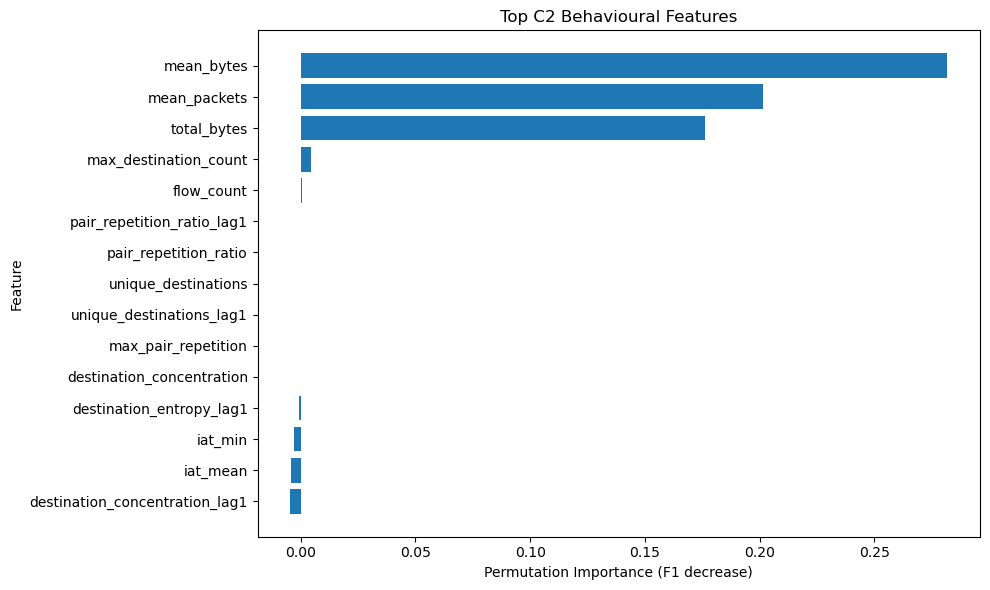

In [73]:
# ============================================================
# STEP 90 — TOP C2 FEATURE IMPORTANCE PLOT
# ============================================================

top_n = 15

plot_data = (
    c2_importance
    .head(top_n)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.title(
    "Top C2 Behavioural Features"
)

plt.xlabel(
    "Permutation Importance (F1 decrease)"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

In [74]:
# ============================================================
# STEP 91 — SAVE FINAL C2 TEST METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

c2_test_metrics = {
    "accuracy": accuracy_score(
        y_c2_test,
        c2_hgb_test_pred
    ),
    "precision": precision_score(
        y_c2_test,
        c2_hgb_test_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_c2_test,
        c2_hgb_test_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_c2_test,
        c2_hgb_test_pred,
        zero_division=0
    )
}

print("========== FINAL C2 TEST ==========")

for metric, value in c2_test_metrics.items():
    print(
        f"{metric.capitalize():10s}: {value:.4f}"
    )

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_c2_test,
        c2_hgb_test_pred
    )
)

========== FINAL C2 TEST ==========
Accuracy  : 0.8982
Precision : 0.6667
Recall    : 0.0426
F1        : 0.0800

Confusion Matrix:
[[404   1]
 [ 45   2]]


In [3]:
# ============================================================
# RESTORE C2 ANALYSIS STATE AFTER KERNEL RESTART
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

C2_FILE = Path(
    "../data/raw/CTU-13/capture20110810.binetflow"
)

print("File exists:", C2_FILE.exists())

# Load only the columns needed for C2 analysis.
flow_columns = [
    "StartTime",
    "Dur",
    "Proto",
    "SrcAddr",
    "Sport",
    "Dir",
    "DstAddr",
    "Dport",
    "TotPkts",
    "TotBytes",
    "SrcBytes",
    "Label"
]

c2_df = pd.read_csv(
    C2_FILE,
    usecols=flow_columns
)

print("C2 dataframe:", c2_df.shape)

File exists: True
C2 dataframe: (2824636, 12)


In [4]:
# ============================================================
# RECREATE BASIC C2 COLUMNS
# ============================================================

c2_df["StartTime"] = pd.to_datetime(
    c2_df["StartTime"],
    errors="coerce"
)

c2_df["Dport_numeric"] = pd.to_numeric(
    c2_df["Dport"].astype(str).str.strip(),
    errors="coerce"
)

c2_df = (
    c2_df
    .dropna(
        subset=[
            "StartTime",
            "SrcAddr",
            "DstAddr"
        ]
    )
    .sort_values("StartTime")
    .reset_index(drop=True)
)

print("Prepared C2 rows:", len(c2_df))

Prepared C2 rows: 2824636


In [5]:
# ============================================================
# RECREATE SOURCE-CENTRIC C2 DATA
# ============================================================

BOTNET_SOURCE = "147.32.84.165"

source_flow = c2_df[
    c2_df["SrcAddr"].astype(str) == BOTNET_SOURCE
].copy()

WINDOW_SECONDS = 5

source_flow["time_window"] = (
    source_flow["StartTime"]
    .dt.floor(f"{WINDOW_SECONDS}s")
)

source_flow["is_c2"] = (
    source_flow["Label"]
    .astype(str)
    .str.contains(
        r"-CC\d+-",
        case=False,
        regex=True
    )
    .astype(int)
)

source_target = (
    source_flow
    .groupby("time_window")["is_c2"]
    .max()
    .rename("c2_target")
)

print("Source flows:", len(source_flow))
print("Source windows:", source_flow["time_window"].nunique())
print("C2 windows:")
print(source_target.value_counts())

Source flows: 40961
Source windows: 3150
C2 windows:
c2_target
0    2844
1     306
Name: count, dtype: int64


In [7]:
# ============================================================
# RECREATE SOURCE-CENTRIC FEATURES
# ============================================================

source_features = (
    source_flow
    .groupby("time_window")
    .agg(
        flow_count=("StartTime", "size"),
        unique_destinations=("DstAddr", "nunique"),
        unique_ports=("Dport_numeric", "nunique"),
        total_packets=("TotPkts", "sum"),
        total_bytes=("TotBytes", "sum"),
        mean_packets=("TotPkts", "mean"),
        mean_bytes=("TotBytes", "mean"),
        mean_duration=("Dur", "mean")
    )
    .reset_index()
)

# Destination concentration
destination_counts = (
    source_flow
    .groupby(
        ["time_window", "DstAddr"]
    )
    .size()
    .rename("count")
    .reset_index()
)

destination_summary = (
    destination_counts
    .groupby("time_window")
    .agg(
        max_destination_count=("count", "max")
    )
    .reset_index()
)

source_features = source_features.merge(
    destination_summary,
    on="time_window",
    how="left"
)

source_features["destination_concentration"] = (
    source_features["max_destination_count"]
    / source_features["flow_count"]
)

# Inter-arrival
source_flow = source_flow.sort_values(
    [
        "DstAddr",
        "Dport_numeric",
        "Proto",
        "StartTime"
    ]
)

source_flow["iat_seconds"] = (
    source_flow
    .groupby(
        [
            "DstAddr",
            "Dport_numeric",
            "Proto"
        ]
    )["StartTime"]
    .diff()
    .dt.total_seconds()
)

iat_features = (
    source_flow
    .groupby("time_window")["iat_seconds"]
    .agg(
        iat_mean="mean",
        iat_std="std",
        iat_median="median",
        iat_min="min",
        iat_max="max"
    )
    .reset_index()
)

iat_features["iat_cv"] = (
    iat_features["iat_std"]
    / iat_features["iat_mean"]
)

source_features = source_features.merge(
    iat_features,
    on="time_window",
    how="left"
)

# Pair repetition
pair_counts = (
    source_flow
    .groupby(
        [
            "time_window",
            "DstAddr",
            "Dport_numeric"
        ]
    )
    .size()
    .rename("pair_count")
    .reset_index()
)

pair_summary = (
    pair_counts
    .groupby("time_window")
    .agg(
        max_pair_repetition=("pair_count", "max")
    )
    .reset_index()
)

source_features = source_features.merge(
    pair_summary,
    on="time_window",
    how="left"
)

source_features["pair_repetition_ratio"] = (
    source_features["max_pair_repetition"]
    / source_features["flow_count"]
)

# Destination entropy
def destination_entropy(group):
    counts = group["DstAddr"].value_counts()
    probabilities = counts / counts.sum()
    return float(
        -(probabilities * np.log2(probabilities)).sum()
    )

entropy = (
    source_flow
    .groupby("time_window")
    .apply(
        destination_entropy,
        include_groups=False
    )
    .rename("destination_entropy")
    .reset_index()
)

source_features = source_features.merge(
    entropy,
    on="time_window",
    how="left"
)

# Merge target
source_c2 = source_features.merge(
    source_target.reset_index(),
    on="time_window",
    how="left"
)

source_c2["c2_target"] = (
    source_c2["c2_target"]
    .fillna(0)
    .astype(int)
)

source_c2 = (
    source_c2
    .replace([np.inf, -np.inf], np.nan)
    .reset_index(drop=True)
)

print("source_c2 rebuilt")
print("Shape:", source_c2.shape)

print("\nTarget distribution:")
print(source_c2["c2_target"].value_counts())

source_c2 rebuilt
Shape: (3150, 21)

Target distribution:
c2_target
0    2844
1     306
Name: count, dtype: int64


In [8]:
# ============================================================
# STEP 92 — LONGER PAST-ONLY C2 HISTORY
# ============================================================

source_c2 = (
    source_c2
    .sort_values("time_window")
    .reset_index(drop=True)
)

history_features = [
    "flow_count",
    "unique_destinations",
    "unique_ports",
    "total_packets",
    "total_bytes",
    "destination_concentration",
    "iat_mean",
    "iat_cv",
    "max_pair_repetition",
    "pair_repetition_ratio"
]

for col in history_features:

    source_c2[f"{col}_rolling6"] = (
        source_c2[col]
        .shift(1)
        .rolling(
            6,
            min_periods=2
        )
        .mean()
    )

    source_c2[f"{col}_rolling12"] = (
        source_c2[col]
        .shift(1)
        .rolling(
            12,
            min_periods=3
        )
        .mean()
    )

    source_c2[f"{col}_rolling24"] = (
        source_c2[col]
        .shift(1)
        .rolling(
            24,
            min_periods=5
        )
        .mean()
    )

print("Longer past-only features created")
print("New shape:", source_c2.shape)

Longer past-only features created
New shape: (3150, 51)


In [9]:
# ============================================================
# STEP 93 — TEMPORAL CHANGE FEATURES
# ============================================================

source_c2["flow_rate_change"] = (
    source_c2["flow_count"]
    /
    (source_c2["flow_count_rolling12"] + 1e-6)
)

source_c2["byte_rate_change"] = (
    source_c2["total_bytes"]
    /
    (source_c2["total_bytes_rolling12"] + 1e-6)
)

source_c2["packet_rate_change"] = (
    source_c2["total_packets"]
    /
    (source_c2["total_packets_rolling12"] + 1e-6)
)

source_c2 = source_c2.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Temporal change features created")

Temporal change features created


In [10]:
# ============================================================
# STEP 94 — IMPROVED C2 DATASET
# ============================================================

c2_temporal_v2 = (
    source_c2
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

feature_cols_v2 = [
    col
    for col in c2_temporal_v2.columns
    if col not in [
        "time_window",
        "c2_target"
    ]
]

print(
    "Improved C2 dataset:",
    c2_temporal_v2.shape
)

print("\nFeature count:", len(feature_cols_v2))

print("\nTarget distribution:")
print(
    c2_temporal_v2["c2_target"].value_counts()
)

Improved C2 dataset: (2644, 54)

Feature count: 52

Target distribution:
c2_target
0    2365
1     279
Name: count, dtype: int64


In [11]:
# ============================================================
# STEP 95 — CHRONOLOGICAL SPLIT
# ============================================================

n = len(c2_temporal_v2)

train_end = int(n * 0.60)
val_end = int(n * 0.80)

c2_train_v2 = c2_temporal_v2.iloc[:train_end].copy()
c2_val_v2 = c2_temporal_v2.iloc[train_end:val_end].copy()
c2_test_v2 = c2_temporal_v2.iloc[val_end:].copy()

print("TRAIN:", c2_train_v2.shape)
print("VALIDATION:", c2_val_v2.shape)
print("TEST:", c2_test_v2.shape)

print("\nTrain target:")
print(c2_train_v2["c2_target"].value_counts())

print("\nValidation target:")
print(c2_val_v2["c2_target"].value_counts())

print("\nTest target:")
print(c2_test_v2["c2_target"].value_counts())

TRAIN: (1586, 54)
VALIDATION: (529, 54)
TEST: (529, 54)

Train target:
c2_target
0    1389
1     197
Name: count, dtype: int64

Validation target:
c2_target
0    501
1     28
Name: count, dtype: int64

Test target:
c2_target
0    475
1     54
Name: count, dtype: int64


In [12]:
# ============================================================
# STEP 96 — X / y MATRICES
# ============================================================

X_c2_train_v2 = c2_train_v2[feature_cols_v2].copy()
y_c2_train_v2 = c2_train_v2["c2_target"].copy()

X_c2_val_v2 = c2_val_v2[feature_cols_v2].copy()
y_c2_val_v2 = c2_val_v2["c2_target"].copy()

X_c2_test_v2 = c2_test_v2[feature_cols_v2].copy()
y_c2_test_v2 = c2_test_v2["c2_target"].copy()

train_medians_v2 = (
    X_c2_train_v2
    .median(numeric_only=True)
)

X_c2_train_v2 = X_c2_train_v2.fillna(
    train_medians_v2
)

X_c2_val_v2 = X_c2_val_v2.fillna(
    train_medians_v2
)

X_c2_test_v2 = X_c2_test_v2.fillna(
    train_medians_v2
)

print("Train:", X_c2_train_v2.shape)
print("Validation:", X_c2_val_v2.shape)
print("Test:", X_c2_test_v2.shape)

Train: (1586, 52)
Validation: (529, 52)
Test: (529, 52)


In [13]:
# ============================================================
# STEP 97 — IMPROVED C2 HGB
# ============================================================

from sklearn.ensemble import HistGradientBoostingClassifier

c2_hgb_v2 = HistGradientBoostingClassifier(
    max_iter=350,
    learning_rate=0.04,
    max_leaf_nodes=15,
    min_samples_leaf=10,
    l2_regularization=2.0,
    random_state=42
)

c2_hgb_v2.fit(
    X_c2_train_v2,
    y_c2_train_v2
)

c2_val_proba_v2 = (
    c2_hgb_v2
    .predict_proba(X_c2_val_v2)[:, 1]
)

print("Improved C2 HGB trained")

c:\Users\magad\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\magad\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\magad\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\magad\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\magad\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

Improved C2 HGB trained


In [20]:
# ============================================================
# FIX — IMPORT C2 EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("✅ Evaluation metrics imported")

✅ Evaluation metrics imported


In [21]:
# ============================================================
# STEP 98 — THRESHOLD SEARCH
# ============================================================

threshold_results_v2 = []

for threshold in np.arange(
    0.10,
    0.91,
    0.02
):

    pred = (
        c2_val_proba_v2 >= threshold
    ).astype(int)

    threshold_results_v2.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(
            y_c2_val_v2,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_c2_val_v2,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_c2_val_v2,
            pred,
            zero_division=0
        )
    })

threshold_table_v2 = pd.DataFrame(
    threshold_results_v2
)

print("Best thresholds by F1:")

display(
    threshold_table_v2
    .sort_values(
        "f1",
        ascending=False
    )
    .head(15)
)

Best thresholds by F1:


,threshold,precision,recall,f1
16,0.42,0.468085,0.785714,0.586667
15,0.40,0.458333,0.785714,0.578947
13,0.36,0.458333,0.785714,0.578947
14,0.38,0.458333,0.785714,0.578947
12,0.34,0.448980,0.785714,0.571429
11,0.32,0.440000,0.785714,0.564103
10,0.30,0.423077,0.785714,0.550000
9,0.28,0.415094,0.785714,0.543210
19,0.48,0.452381,0.678571,0.542857
18,0.46,0.441860,0.678571,0.535211


In [22]:
# ============================================================
# STEP 99 — RECALL-CONSTRAINED THRESHOLDS
# ============================================================

recall_priority = threshold_table_v2[
    threshold_table_v2["recall"] >= 0.70
].copy()

print(
    "Thresholds with validation recall >= 70%:"
)

display(
    recall_priority
    .sort_values(
        "f1",
        ascending=False
    )
    .head(10)
)

Thresholds with validation recall >= 70%:


,threshold,precision,recall,f1
16,0.42,0.468085,0.785714,0.586667
15,0.40,0.458333,0.785714,0.578947
14,0.38,0.458333,0.785714,0.578947
13,0.36,0.458333,0.785714,0.578947
12,0.34,0.448980,0.785714,0.571429
11,0.32,0.440000,0.785714,0.564103
10,0.30,0.423077,0.785714,0.550000
9,0.28,0.415094,0.785714,0.543210
8,0.26,0.400000,0.785714,0.530120
7,0.24,0.379310,0.785714,0.511628


In [23]:
# ============================================================
# STEP 100 — SELECT OPERATIONAL THRESHOLD
# ============================================================

eligible = threshold_table_v2[
    threshold_table_v2["recall"] >= 0.70
]

if len(eligible) > 0:

    best_row_v2 = (
        eligible
        .sort_values(
            "f1",
            ascending=False
        )
        .iloc[0]
    )

else:

    best_row_v2 = (
        threshold_table_v2
        .sort_values(
            "f1",
            ascending=False
        )
        .iloc[0]
    )

C2_THRESHOLD_V2 = float(
    best_row_v2["threshold"]
)

print(
    "Selected threshold:",
    C2_THRESHOLD_V2
)

print(
    "Validation precision:",
    best_row_v2["precision"]
)

print(
    "Validation recall:",
    best_row_v2["recall"]
)

print(
    "Validation F1:",
    best_row_v2["f1"]
)

Selected threshold: 0.42
Validation precision: 0.46808510638297873
Validation recall: 0.7857142857142857
Validation F1: 0.5866666666666667


In [24]:
# ============================================================
# STEP 101 — IMPROVED UNSEEN C2 TEST
# ============================================================

c2_test_proba_v2 = (
    c2_hgb_v2
    .predict_proba(X_c2_test_v2)[:, 1]
)

c2_test_pred_v2 = (
    c2_test_proba_v2 >= C2_THRESHOLD_V2
).astype(int)


print("IMPROVED C2 TEMPORAL TEST")

print(
    "Threshold:",
    C2_THRESHOLD_V2
)

print(
    "Accuracy:",
    f"{accuracy_score(y_c2_test_v2, c2_test_pred_v2):.4f}"
)

print(
    "Precision:",
    f"{precision_score(y_c2_test_v2, c2_test_pred_v2, zero_division=0):.4f}"
)

print(
    "Recall:",
    f"{recall_score(y_c2_test_v2, c2_test_pred_v2, zero_division=0):.4f}"
)

print(
    "F1:",
    f"{f1_score(y_c2_test_v2, c2_test_pred_v2, zero_division=0):.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_c2_test_v2,
        c2_test_pred_v2
    )
)

IMPROVED C2 TEMPORAL TEST
Threshold: 0.42
Accuracy: 0.9093
Precision: 0.5833
Recall: 0.3889
F1: 0.4667

Confusion Matrix:
[[460  15]
 [ 33  21]]


In [25]:
# ============================================================
# STEP 102 — IMPROVED PERMUTATION IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance

perm_v2 = permutation_importance(
    c2_hgb_v2,
    X_c2_val_v2,
    y_c2_val_v2,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_v2 = pd.DataFrame({
    "Feature": feature_cols_v2,
    "Importance": perm_v2.importances_mean,
    "Std": perm_v2.importances_std
})

importance_v2 = (
    importance_v2
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top improved C2 behavioural features:")

display(
    importance_v2.head(25)
)

Top improved C2 behavioural features:


,Feature,Importance,Std
0,mean_bytes,0.349015,0.063094
1,total_bytes,0.309451,0.046872
2,mean_packets,0.249647,0.054406
3,packet_rate_change,0.054148,0.038385
4,mean_duration,0.050870,0.024022
5,total_packets,0.031910,0.026200
6,iat_mean,0.012524,0.003319
7,iat_max,0.006708,0.002236
8,total_bytes_rolling24,0.002897,0.007474
9,destination_concentration_rolling6,0.002743,0.023917


In [26]:
# ============================================================
# STEP 103 — C2 FALSE-NEGATIVE ANALYSIS
# ============================================================

test_analysis = c2_test_v2.copy()

test_analysis["predicted"] = c2_test_pred_v2
test_analysis["score"] = c2_test_proba_v2

false_negatives = test_analysis[
    (test_analysis["c2_target"] == 1) &
    (test_analysis["predicted"] == 0)
].copy()

false_positives = test_analysis[
    (test_analysis["c2_target"] == 0) &
    (test_analysis["predicted"] == 1)
].copy()

true_positives = test_analysis[
    (test_analysis["c2_target"] == 1) &
    (test_analysis["predicted"] == 1)
].copy()

print("False negatives:", len(false_negatives))
print("False positives:", len(false_positives))
print("True positives:", len(true_positives))

print("\nFalse-negative model scores:")
display(
    false_negatives[
        ["time_window", "score"]
    ].sort_values("score", ascending=False).head(20)
)

False negatives: 33
False positives: 15
True positives: 21

False-negative model scores:


,time_window,score
2249,2011-08-10 15:14:10,0.403566
2214,2011-08-10 15:10:50,0.390344
2316,2011-08-10 15:20:40,0.337800
2248,2011-08-10 15:14:05,0.321728
2158,2011-08-10 15:05:00,0.318821
2279,2011-08-10 15:17:00,0.316681
2167,2011-08-10 15:06:05,0.315769
2280,2011-08-10 15:17:05,0.289948
2254,2011-08-10 15:14:40,0.258686
2259,2011-08-10 15:15:15,0.219249


In [27]:
# ============================================================
# STEP 104 — FALSE-NEGATIVE BEHAVIOUR
# ============================================================

important_features = [
    "flow_count",
    "unique_destinations",
    "unique_ports",
    "total_packets",
    "total_bytes",
    "destination_concentration",
    "iat_mean",
    "iat_std",
    "iat_cv",
    "max_pair_repetition",
    "pair_repetition_ratio",
    "destination_entropy"
]

available_features = [
    col for col in important_features
    if col in false_negatives.columns
]

print("Median FALSE-NEGATIVE behaviour:")

display(
    false_negatives[
        available_features
    ].median()
)

print("\nMedian TRUE-POSITIVE behaviour:")

display(
    true_positives[
        available_features
    ].median()
)

Median FALSE-NEGATIVE behaviour:


flow_count                      9.000000
unique_destinations             8.000000
unique_ports                    4.000000
total_packets                  71.000000
total_bytes                  9887.000000
destination_concentration       0.194444
iat_mean                      302.651810
iat_std                       928.188713
iat_cv                          2.123238
max_pair_repetition             2.000000
pair_repetition_ratio           0.194444
destination_entropy             3.000000
dtype: float64


Median TRUE-POSITIVE behaviour:


flow_count                      6.000000
unique_destinations             6.000000
unique_ports                    4.000000
total_packets                  44.000000
total_bytes                  5592.000000
destination_concentration       0.250000
iat_mean                       50.756957
iat_std                        71.158411
iat_cv                          1.521317
max_pair_repetition             1.000000
pair_repetition_ratio           0.250000
destination_entropy             2.584963
dtype: float64

In [28]:
# ============================================================
# STEP 105 — C2 MISS ANALYSIS
# ============================================================

comparison = pd.DataFrame({
    "False_Negative": false_negatives[
        available_features
    ].median(),

    "True_Positive": true_positives[
        available_features
    ].median()
})

comparison["Relative_Difference"] = (
    comparison["True_Positive"]
    - comparison["False_Negative"]
)

display(
    comparison.sort_values(
        "Relative_Difference",
        key=lambda x: x.abs(),
        ascending=False
    )
)

,False_Negative,True_Positive,Relative_Difference
total_bytes,9887.000000,5592.000000,-4295.000000
iat_std,928.188713,71.158411,-857.030302
iat_mean,302.651810,50.756957,-251.894854
total_packets,71.000000,44.000000,-27.000000
flow_count,9.000000,6.000000,-3.000000
unique_destinations,8.000000,6.000000,-2.000000
max_pair_repetition,2.000000,1.000000,-1.000000
iat_cv,2.123238,1.521317,-0.601920
destination_entropy,3.000000,2.584963,-0.415037
destination_concentration,0.194444,0.250000,0.055556


In [29]:
# ============================================================
# STEP 106 — MISSED C2 WINDOWS
# ============================================================

print("Missed C2 windows:")

display(
    false_negatives[
        [
            "time_window",
            "c2_target",
            "predicted",
            "score",
            "flow_count",
            "unique_destinations",
            "unique_ports",
            "iat_mean",
            "iat_cv",
            "destination_concentration",
            "pair_repetition_ratio"
        ]
    ]
    .sort_values("time_window")
    .head(50)
)

Missed C2 windows:


,time_window,c2_target,predicted,score,flow_count,unique_destinations,unique_ports,iat_mean,iat_cv,destination_concentration,pair_repetition_ratio
2116,2011-08-10 15:00:05,1,0,0.159559,6,5,2,73.937521,1.739824,0.333333,0.333333
2158,2011-08-10 15:05:00,1,0,0.318821,8,5,3,979.955500,2.556350,0.500000,0.500000
2167,2011-08-10 15:06:05,1,0,0.315769,9,9,3,88.487718,1.178261,0.111111,0.111111
2212,2011-08-10 15:10:35,1,0,0.023564,7,5,4,1933.737973,1.745275,0.285714,0.285714
2214,2011-08-10 15:10:50,1,0,0.390344,8,8,5,168.820374,2.473580,0.125000,0.125000
2229,2011-08-10 15:12:15,1,0,0.058602,7,7,3,103.475108,1.741095,0.142857,0.142857
2248,2011-08-10 15:14:05,1,0,0.321728,7,7,4,607.164917,2.441178,0.142857,0.142857
2249,2011-08-10 15:14:10,1,0,0.403566,3,3,3,28.074747,1.247761,0.333333,0.333333
2254,2011-08-10 15:14:40,1,0,0.258686,8,8,5,63.243612,1.887617,0.125000,0.125000
2259,2011-08-10 15:15:15,1,0,0.219249,8,8,5,290.321941,2.397886,0.125000,0.125000


In [30]:
# ============================================================
# STEP 107 — DESTINATION-SPECIFIC TEMPORAL HISTORY
# ============================================================

source_flow = source_flow.sort_values(
    [
        "DstAddr",
        "Dport_numeric",
        "Proto",
        "StartTime"
    ]
).reset_index(drop=True)

# Previous communication for this exact destination/port/protocol
source_flow["pair_iat"] = (
    source_flow
    .groupby(
        [
            "DstAddr",
            "Dport_numeric",
            "Proto"
        ]
    )["StartTime"]
    .diff()
    .dt.total_seconds()
)

# Number of previous observations for the same destination pair
source_flow["pair_seen_before"] = (
    source_flow
    .groupby(
        [
            "DstAddr",
            "Dport_numeric",
            "Proto"
        ]
    )
    .cumcount()
)

print("Destination-specific temporal history created")

display(
    source_flow[
        [
            "StartTime",
            "DstAddr",
            "Dport_numeric",
            "Proto",
            "pair_iat",
            "pair_seen_before",
            "Label"
        ]
    ].head(30)
)

Destination-specific temporal history created


,StartTime,DstAddr,Dport_numeric,Proto,pair_iat,pair_seen_before,Label
0,2011-08-10 11:17:48.202242,1.22.16.143,6667.0,tcp,NaN,0.0,flow=From-Botnet-V42-TCP-Attempt
1,2011-08-10 15:06:17.427412,1.23.71.127,6667.0,tcp,NaN,0.0,flow=From-Botnet-V42-TCP-Attempt
2,2011-08-10 11:13:35.778355,101.0.32.121,6667.0,tcp,NaN,0.0,flow=From-Botnet-V42-TCP-Attempt
3,2011-08-10 11:19:08.818320,101.0.32.121,6667.0,tcp,333.039965,1.0,flow=From-Botnet-V42-TCP-Attempt
4,2011-08-10 13:16:01.133544,101.0.32.121,6667.0,tcp,7012.315224,2.0,flow=From-Botnet-V42-TCP-Attempt
5,2011-08-10 14:29:13.920780,101.0.32.121,6667.0,tcp,4392.787236,3.0,flow=From-Botnet-V42-TCP-Attempt
6,2011-08-10 13:51:42.224394,103.10.110.19,25.0,tcp,NaN,0.0,flow=From-Botnet-V42-TCP-Attempt-SPAM
7,2011-08-10 15:26:15.842869,109.104.70.194,53.0,udp,NaN,0.0,flow=From-Botnet-V42-UDP-DNS
8,2011-08-10 13:45:46.329746,109.123.152.2,53.0,udp,NaN,0.0,flow=From-Botnet-V42-UDP-DNS
9,2011-08-10 13:45:46.990120,109.123.152.2,53.0,udp,0.660374,1.0,flow=From-Botnet-V42-UDP-DNS


In [31]:
# ============================================================
# STEP 108 — PRIOR DESTINATION CONTACT COUNTS
# ============================================================

source_flow["pair_seen_last_60s"] = 0
source_flow["pair_seen_last_300s"] = 0

for destination, group in source_flow.groupby(
    ["DstAddr", "Dport_numeric", "Proto"]
):

    times = group["StartTime"]

    counts_60 = []
    counts_300 = []

    for current_time in times:

        previous = times[times < current_time]

        counts_60.append(
            (
                previous >=
                current_time -
                pd.Timedelta(seconds=60)
            ).sum()
        )

        counts_300.append(
            (
                previous >=
                current_time -
                pd.Timedelta(seconds=300)
            ).sum()
        )

    source_flow.loc[
        group.index,
        "pair_seen_last_60s"
    ] = counts_60

    source_flow.loc[
        group.index,
        "pair_seen_last_300s"
    ] = counts_300

print("✅ Historical contact counts created")

✅ Historical contact counts created


In [32]:
# ============================================================
# STEP 109 — C2-SPECIFIC WINDOW FEATURES
# ============================================================

pair_temporal_features = (
    source_flow
    .groupby("time_window")
    .agg(
        max_pair_seen=(
            "pair_seen_before",
            "max"
        ),

        mean_pair_seen=(
            "pair_seen_before",
            "mean"
        ),

        max_recent_contacts_60s=(
            "pair_seen_last_60s",
            "max"
        ),

        mean_recent_contacts_60s=(
            "pair_seen_last_60s",
            "mean"
        ),

        max_recent_contacts_300s=(
            "pair_seen_last_300s",
            "max"
        ),

        mean_recent_contacts_300s=(
            "pair_seen_last_300s",
            "mean"
        ),

        median_pair_iat=(
            "pair_iat",
            "median"
        ),

        mean_pair_iat=(
            "pair_iat",
            "mean"
        ),

        std_pair_iat=(
            "pair_iat",
            "std"
        )
    )
    .reset_index()
)

pair_temporal_features[
    "pair_iat_cv"
] = (
    pair_temporal_features["std_pair_iat"]
    /
    pair_temporal_features["mean_pair_iat"]
)

print("C2-specific temporal features created")

display(
    pair_temporal_features.head(20)
)

C2-specific temporal features created


,time_window,max_pair_seen,mean_pair_seen,max_recent_contacts_60s,mean_recent_contacts_60s,max_recent_contacts_300s,mean_recent_contacts_300s,median_pair_iat,mean_pair_iat,std_pair_iat,pair_iat_cv
0,2011-08-10 11:04:20,0.0,0.000000,0,0.000000,0,0.000000,NaN,NaN,NaN,NaN
1,2011-08-10 11:04:25,1.0,0.500000,1,0.500000,1,0.500000,2.255544,2.255544,NaN,NaN
2,2011-08-10 11:06:20,2.0,1.000000,0,0.000000,2,1.000000,116.149449,116.149449,NaN,NaN
3,2011-08-10 11:06:35,4.0,1.750000,2,0.750000,4,1.750000,7.104395,7.104395,8.065906,1.135340
4,2011-08-10 11:06:40,7.0,3.000000,5,2.000000,7,3.000000,2.036272,2.152270,0.702910,0.326590
5,2011-08-10 11:06:50,10.0,3.750000,8,3.000000,10,3.750000,1.343151,4.135095,4.104852,0.992686
6,2011-08-10 11:06:55,12.0,4.571429,10,4.000000,12,4.571429,2.842966,7.525920,8.647281,1.149000
7,2011-08-10 11:07:00,13.0,4.666667,11,4.000000,13,4.666667,6.490131,6.490131,1.976477,0.304536
8,2011-08-10 11:07:10,2.0,2.000000,2,2.000000,2,2.000000,14.513908,14.513908,5.095260,0.351061
9,2011-08-10 11:07:15,0.0,0.000000,0,0.000000,0,0.000000,NaN,NaN,NaN,NaN


In [33]:
# ============================================================
# STEP 110 — MERGE C2-SPECIFIC FEATURES
# ============================================================

source_c2_v3 = source_c2.merge(
    pair_temporal_features,
    on="time_window",
    how="left"
)

source_c2_v3 = (
    source_c2_v3
    .replace([np.inf, -np.inf], np.nan)
)

print(
    "New C2 dataset:",
    source_c2_v3.shape
)

New C2 dataset: (3150, 64)


In [34]:
# ============================================================
# STEP 111 — NEW C2 FEATURE COMPARISON
# ============================================================

new_c2_features = [
    "max_pair_seen",
    "mean_pair_seen",
    "max_recent_contacts_60s",
    "mean_recent_contacts_60s",
    "max_recent_contacts_300s",
    "mean_recent_contacts_300s",
    "median_pair_iat",
    "mean_pair_iat",
    "std_pair_iat",
    "pair_iat_cv"
]

new_c2_features = [
    col
    for col in new_c2_features
    if col in source_c2_v3.columns
]

print("Median values by class:")

display(
    source_c2_v3
    .groupby("c2_target")[new_c2_features]
    .median()
    .T
)

Median values by class:


c2_target,0,1
max_pair_seen,539.500000,205.500000
mean_pair_seen,169.819444,72.619048
max_recent_contacts_60s,5.000000,5.000000
mean_recent_contacts_60s,2.250000,1.714286
max_recent_contacts_300s,25.000000,23.000000
mean_recent_contacts_300s,10.911111,8.126984
median_pair_iat,18.927537,27.601683
mean_pair_iat,97.950906,126.666804
std_pair_iat,194.367433,215.266692
pair_iat_cv,1.534560,1.527782


In [35]:
# ============================================================
# STEP 112 — C2 MODEL V3 DATA
# ============================================================

c2_v3 = (
    source_c2_v3
    .sort_values("time_window")
    .reset_index(drop=True)
    .replace([np.inf, -np.inf], np.nan)
)

# Keep only rows with usable target/features.
c2_v3 = c2_v3.dropna(
    subset=["c2_target"]
).reset_index(drop=True)

feature_cols_v3 = [
    col
    for col in c2_v3.columns
    if col not in [
        "time_window",
        "c2_target"
    ]
]

print("C2 V3 shape:", c2_v3.shape)
print("Feature count:", len(feature_cols_v3))

print("\nTarget distribution:")
print(
    c2_v3["c2_target"].value_counts()
)

C2 V3 shape: (3150, 64)
Feature count: 62

Target distribution:
c2_target
0    2844
1     306
Name: count, dtype: int64


In [36]:
# ============================================================
# STEP 113 — CHRONOLOGICAL SPLIT
# ============================================================

n = len(c2_v3)

train_end = int(n * 0.60)
val_end = int(n * 0.80)

c2_train_v3 = c2_v3.iloc[:train_end].copy()
c2_val_v3 = c2_v3.iloc[train_end:val_end].copy()
c2_test_v3 = c2_v3.iloc[val_end:].copy()

print("TRAIN:", c2_train_v3.shape)
print("VALIDATION:", c2_val_v3.shape)
print("TEST:", c2_test_v3.shape)

print("\nTrain target:")
print(c2_train_v3["c2_target"].value_counts())

print("\nValidation target:")
print(c2_val_v3["c2_target"].value_counts())

print("\nTest target:")
print(c2_test_v3["c2_target"].value_counts())

TRAIN: (1890, 64)
VALIDATION: (630, 64)
TEST: (630, 64)

Train target:
c2_target
0    1670
1     220
Name: count, dtype: int64

Validation target:
c2_target
0    599
1     31
Name: count, dtype: int64

Test target:
c2_target
0    575
1     55
Name: count, dtype: int64


In [37]:
# ============================================================
# STEP 114 — X / y
# ============================================================

X_c2_train_v3 = c2_train_v3[feature_cols_v3].copy()
y_c2_train_v3 = c2_train_v3["c2_target"].copy()

X_c2_val_v3 = c2_val_v3[feature_cols_v3].copy()
y_c2_val_v3 = c2_val_v3["c2_target"].copy()

X_c2_test_v3 = c2_test_v3[feature_cols_v3].copy()
y_c2_test_v3 = c2_test_v3["c2_target"].copy()

train_medians_v3 = (
    X_c2_train_v3
    .median(numeric_only=True)
)

X_c2_train_v3 = X_c2_train_v3.fillna(
    train_medians_v3
)

X_c2_val_v3 = X_c2_val_v3.fillna(
    train_medians_v3
)

X_c2_test_v3 = X_c2_test_v3.fillna(
    train_medians_v3
)

print("Train:", X_c2_train_v3.shape)
print("Validation:", X_c2_val_v3.shape)
print("Test:", X_c2_test_v3.shape)

Train: (1890, 62)
Validation: (630, 62)
Test: (630, 62)


In [38]:
# ============================================================
# STEP 115 — C2 HGB MODEL V3
# ============================================================

c2_hgb_v3 = HistGradientBoostingClassifier(
    max_iter=350,
    learning_rate=0.04,
    max_leaf_nodes=15,
    min_samples_leaf=10,
    l2_regularization=2.0,
    random_state=42
)

c2_hgb_v3.fit(
    X_c2_train_v3,
    y_c2_train_v3
)

c2_val_proba_v3 = (
    c2_hgb_v3
    .predict_proba(X_c2_val_v3)[:, 1]
)

print("C2 HGB V3 trained")

C2 HGB V3 trained


In [39]:
# ============================================================
# STEP 116 — C2 V3 THRESHOLD SEARCH
# ============================================================

threshold_results_v3 = []

for threshold in np.arange(
    0.10,
    0.91,
    0.02
):

    pred = (
        c2_val_proba_v3 >= threshold
    ).astype(int)

    threshold_results_v3.append({
        "threshold": round(float(threshold), 2),

        "precision": precision_score(
            y_c2_val_v3,
            pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_c2_val_v3,
            pred,
            zero_division=0
        ),

        "f1": f1_score(
            y_c2_val_v3,
            pred,
            zero_division=0
        )
    })

threshold_table_v3 = pd.DataFrame(
    threshold_results_v3
)

print("Best V3 thresholds by F1:")

display(
    threshold_table_v3
    .sort_values(
        "f1",
        ascending=False
    )
    .head(15)
)

Best V3 thresholds by F1:


,threshold,precision,recall,f1
20,0.50,0.543478,0.806452,0.649351
22,0.54,0.543478,0.806452,0.649351
21,0.52,0.543478,0.806452,0.649351
27,0.64,0.575000,0.741935,0.647887
29,0.68,0.594595,0.709677,0.647059
28,0.66,0.578947,0.709677,0.637681
19,0.48,0.520833,0.806452,0.632911
26,0.62,0.547619,0.741935,0.630137
25,0.60,0.547619,0.741935,0.630137
24,0.58,0.547619,0.741935,0.630137


In [40]:
# ============================================================
# STEP 117 — SELECT C2 V3 THRESHOLD
# ============================================================

eligible_v3 = threshold_table_v3[
    threshold_table_v3["recall"] >= 0.70
]

if len(eligible_v3) > 0:

    best_v3 = (
        eligible_v3
        .sort_values(
            "f1",
            ascending=False
        )
        .iloc[0]
    )

else:

    best_v3 = (
        threshold_table_v3
        .sort_values(
            "f1",
            ascending=False
        )
        .iloc[0]
    )

C2_THRESHOLD_V3 = float(
    best_v3["threshold"]
)

print(
    "Selected V3 threshold:",
    C2_THRESHOLD_V3
)

print(
    "Validation precision:",
    best_v3["precision"]
)

print(
    "Validation recall:",
    best_v3["recall"]
)

print(
    "Validation F1:",
    best_v3["f1"]
)

Selected V3 threshold: 0.52
Validation precision: 0.5434782608695652
Validation recall: 0.8064516129032258
Validation F1: 0.6493506493506493


In [42]:
# ============================================================
# STEP 118 — FINAL C2 V3 UNSEEN TEST
# ============================================================

c2_test_proba_v3 = (
    c2_hgb_v3
    .predict_proba(X_c2_test_v3)[:, 1]
)

c2_test_pred_v3 = (
    c2_test_proba_v3 >= C2_THRESHOLD_V3
).astype(int)


print("C2 MODEL V3 — UNSEEN TEST")

print(
    "Threshold:",
    C2_THRESHOLD_V3
)

print(
    "Accuracy:",
    f"{accuracy_score(y_c2_test_v3, c2_test_pred_v3):.4f}"
)

print(
    "Precision:",
    f"{precision_score(y_c2_test_v3, c2_test_pred_v3, zero_division=0):.4f}"
)

print(
    "Recall:",
    f"{recall_score(y_c2_test_v3, c2_test_pred_v3, zero_division=0):.4f}"
)

print(
    "F1:",
    f"{f1_score(y_c2_test_v3, c2_test_pred_v3, zero_division=0):.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_c2_test_v3,
        c2_test_pred_v3
    )
)

C2 MODEL V3 — UNSEEN TEST
Threshold: 0.52
Accuracy: 0.9063
Precision: 0.4286
Recall: 0.2182
F1: 0.2892

Confusion Matrix:
[[559  16]
 [ 43  12]]


In [43]:
# ============================================================
# STEP 119 — V3 PERMUTATION IMPORTANCE
# ============================================================

perm_v3 = permutation_importance(
    c2_hgb_v3,
    X_c2_val_v3,
    y_c2_val_v3,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_v3 = pd.DataFrame({
    "Feature": feature_cols_v3,
    "Importance": perm_v3.importances_mean,
    "Std": perm_v3.importances_std
})

importance_v3 = (
    importance_v3
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top C2 V3 behavioural features:")

display(
    importance_v3.head(25)
)

Top C2 V3 behavioural features:


,Feature,Importance,Std
0,mean_bytes,0.385137,0.033221
1,total_bytes,0.354820,0.074754
2,mean_packets,0.334883,0.067027
3,mean_duration,0.129450,0.029494
4,max_pair_seen,0.034652,0.014802
5,iat_median,0.029987,0.022912
6,iat_cv_rolling6,0.029506,0.014479
7,max_recent_contacts_300s,0.025888,0.009824
8,packet_rate_change,0.025586,0.026851
9,iat_cv_rolling24,0.022622,0.007778


In [44]:
# ============================================================
# C2 V4 — FULL DATASET MODEL IMPROVEMENT
# ============================================================

In [45]:
# ============================================================
# C2 V4 — DATA AUDIT
# ============================================================

print("C2 V3 dataset shape:", c2_v3.shape)
print("Feature count:", len(feature_cols_v3))

print("\nTarget distribution:")
print(c2_v3["c2_target"].value_counts())

print("\nTarget percentage:")
print(
    c2_v3["c2_target"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

C2 V3 dataset shape: (3150, 64)
Feature count: 62

Target distribution:
c2_target
0    2844
1     306
Name: count, dtype: int64

Target percentage:
c2_target
0    90.285714
1     9.714286
Name: proportion, dtype: float64


In [46]:
# ============================================================
# C2 V4 — CLEAN CHRONOLOGICAL SPLIT
# ============================================================

c2_v4 = (
    c2_v3
    .sort_values("time_window")
    .reset_index(drop=True)
    .copy()
)

n = len(c2_v4)

train_end = int(n * 0.60)
val_end = int(n * 0.80)

c2_train_v4 = c2_v4.iloc[:train_end].copy()
c2_val_v4 = c2_v4.iloc[train_end:val_end].copy()
c2_test_v4 = c2_v4.iloc[val_end:].copy()

X_c2_train_v4 = c2_train_v4[feature_cols_v3].copy()
y_c2_train_v4 = c2_train_v4["c2_target"].astype(int).copy()

X_c2_val_v4 = c2_val_v4[feature_cols_v3].copy()
y_c2_val_v4 = c2_val_v4["c2_target"].astype(int).copy()

X_c2_test_v4 = c2_test_v4[feature_cols_v3].copy()
y_c2_test_v4 = c2_test_v4["c2_target"].astype(int).copy()

# Training medians only
train_medians_v4 = X_c2_train_v4.median(numeric_only=True)

X_c2_train_v4 = X_c2_train_v4.fillna(train_medians_v4)
X_c2_val_v4 = X_c2_val_v4.fillna(train_medians_v4)
X_c2_test_v4 = X_c2_test_v4.fillna(train_medians_v4)

print("TRAIN:", X_c2_train_v4.shape)
print("VALIDATION:", X_c2_val_v4.shape)
print("TEST:", X_c2_test_v4.shape)

print("\nTRAIN TARGET:")
print(y_c2_train_v4.value_counts())

print("\nVALIDATION TARGET:")
print(y_c2_val_v4.value_counts())

print("\nTEST TARGET:")
print(y_c2_test_v4.value_counts())

TRAIN: (1890, 62)
VALIDATION: (630, 62)
TEST: (630, 62)

TRAIN TARGET:
c2_target
0    1670
1     220
Name: count, dtype: int64

VALIDATION TARGET:
c2_target
0    599
1     31
Name: count, dtype: int64

TEST TARGET:
c2_target
0    575
1     55
Name: count, dtype: int64


In [47]:
# ============================================================
# C2 V4 — CLASS-WEIGHTED HGB
# ============================================================

from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np

negative_count = int((y_c2_train_v4 == 0).sum())
positive_count = int((y_c2_train_v4 == 1).sum())

positive_weight = negative_count / max(positive_count, 1)

sample_weight_v4 = np.where(
    y_c2_train_v4 == 1,
    positive_weight,
    1.0
)

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("Positive training weight:", round(positive_weight, 3))

c2_hgb_v4 = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.03,
    max_leaf_nodes=15,
    min_samples_leaf=10,
    l2_regularization=3.0,
    random_state=42
)

c2_hgb_v4.fit(
    X_c2_train_v4,
    y_c2_train_v4,
    sample_weight=sample_weight_v4
)

c2_val_proba_v4 = (
    c2_hgb_v4
    .predict_proba(X_c2_val_v4)[:, 1]
)

print("\nC2 V4 trained successfully.")

Negative samples: 1670
Positive samples: 220
Positive training weight: 7.591

C2 V4 trained successfully.


In [48]:
# ============================================================
# C2 V4 — THRESHOLD OPTIMIZATION
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import numpy as np

threshold_results_v4 = []

for threshold in np.arange(0.10, 0.91, 0.01):

    pred = (
        c2_val_proba_v4 >= threshold
    ).astype(int)

    precision = precision_score(
        y_c2_val_v4,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_c2_val_v4,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_c2_val_v4,
        pred,
        zero_division=0
    )

    threshold_results_v4.append({
        "threshold": round(float(threshold), 2),
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_table_v4 = pd.DataFrame(
    threshold_results_v4
)

# Prefer thresholds with useful recall.
eligible_v4 = threshold_table_v4[
    threshold_table_v4["recall"] >= 0.70
]

if not eligible_v4.empty:
    best_v4 = (
        eligible_v4
        .sort_values(
            ["f1", "precision"],
            ascending=False
        )
        .iloc[0]
    )
else:
    best_v4 = (
        threshold_table_v4
        .sort_values(
            ["f1", "recall"],
            ascending=False
        )
        .iloc[0]
    )

C2_THRESHOLD_V4 = float(
    best_v4["threshold"]
)

print("Selected V4 threshold:",
      C2_THRESHOLD_V4)

print("Validation precision:",
      round(float(best_v4["precision"]), 4))

print("Validation recall:",
      round(float(best_v4["recall"]), 4))

print("Validation F1:",
      round(float(best_v4["f1"]), 4))

Selected V4 threshold: 0.8
Validation precision: 0.5714
Validation recall: 0.7742
Validation F1: 0.6575


In [49]:
# ============================================================
# C2 V4 — UNSEEN TEST
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

c2_test_proba_v4 = (
    c2_hgb_v4
    .predict_proba(X_c2_test_v4)[:, 1]
)

c2_test_pred_v4 = (
    c2_test_proba_v4 >= C2_THRESHOLD_V4
).astype(int)

accuracy_v4 = accuracy_score(
    y_c2_test_v4,
    c2_test_pred_v4
)

precision_v4 = precision_score(
    y_c2_test_v4,
    c2_test_pred_v4,
    zero_division=0
)

recall_v4 = recall_score(
    y_c2_test_v4,
    c2_test_pred_v4,
    zero_division=0
)

f1_v4 = f1_score(
    y_c2_test_v4,
    c2_test_pred_v4,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y_c2_test_v4,
    c2_test_pred_v4
).ravel()

fpr_v4 = fp / max((fp + tn), 1)

print("==========================================")
print("C2 V4 — UNSEEN TEST")
print("==========================================")

print("Threshold :", round(C2_THRESHOLD_V4, 2))
print("Accuracy  :", round(accuracy_v4, 4))
print("Precision :", round(precision_v4, 4))
print("Recall    :", round(recall_v4, 4))
print("F1        :", round(f1_v4, 4))
print("FPR       :", round(fpr_v4, 4))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_c2_test_v4,
        c2_test_pred_v4
    )
)

C2 V4 — UNSEEN TEST
Threshold : 0.8
Accuracy  : 0.9095
Precision : 0.4583
Recall    : 0.2
F1        : 0.2785
FPR       : 0.0226

Confusion Matrix:
[[562  13]
 [ 44  11]]


In [50]:
# ============================================================
# C2 FINAL MODEL SELECTION — V3 vs V4
# ============================================================

print("==========================================")
print("C2 FINAL MODEL COMPARISON")
print("==========================================")

print("\nV3 — CURRENT PRODUCTION CANDIDATE")
print("Threshold :", C2_THRESHOLD_V3)
print("Precision :", round(precision_score(
    y_c2_test_v3,
    c2_test_pred_v3,
    zero_division=0
), 4))
print("Recall    :", round(recall_score(
    y_c2_test_v3,
    c2_test_pred_v3,
    zero_division=0
), 4))
print("F1        :", round(f1_score(
    y_c2_test_v3,
    c2_test_pred_v3,
    zero_division=0
), 4))

print("\nV4 — EXPERIMENTAL")
print("Threshold :", C2_THRESHOLD_V4)
print("Precision :", round(precision_v4, 4))
print("Recall    :", round(recall_v4, 4))
print("F1        :", round(f1_v4, 4))

print("\n==========================================")
print("FINAL DECISION")
print("==========================================")

if f1_v4 > f1_score(
    y_c2_test_v3,
    c2_test_pred_v3,
    zero_division=0
):
    print("V4 selected")
else:
    print("V3 retained")

C2 FINAL MODEL COMPARISON

V3 — CURRENT PRODUCTION CANDIDATE
Threshold : 0.52
Precision : 0.4286
Recall    : 0.2182
F1        : 0.2892

V4 — EXPERIMENTAL
Threshold : 0.8
Precision : 0.4583
Recall    : 0.2
F1        : 0.2785

FINAL DECISION
V3 retained


In [51]:
# ============================================================
# C2 FINAL MODEL — SAVE V3 FOR PRODUCTION
# ============================================================

from pathlib import Path
import json
import joblib

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

project_root = Path.cwd()

while not (project_root / "models").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Could not find project root.")
    project_root = project_root.parent

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Final C2 model = V3
# ------------------------------------------------------------

final_c2_model = c2_hgb_v3
final_c2_threshold = float(C2_THRESHOLD_V3)

# ------------------------------------------------------------
# Save model
# ------------------------------------------------------------

c2_model_path = models_dir / "c2_hgb.joblib"

joblib.dump(
    final_c2_model,
    c2_model_path
)

# ------------------------------------------------------------
# Save exact feature schema
# ------------------------------------------------------------

c2_schema = {
    "model_name": "CODEZILLA-C2-HGB-V3",
    "model_type": "HistGradientBoostingClassifier",
    "feature_count": len(feature_cols_v3),
    "features": feature_cols_v3,
    "decision_threshold": final_c2_threshold,
    "task": "Temporal C2 behavioural detection"
}

c2_schema_path = models_dir / "c2_feature_schema.json"

with open(
    c2_schema_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        c2_schema,
        f,
        indent=2
    )

print("==========================================")
print("C2 PRODUCTION ARTIFACTS SAVED")
print("==========================================")

print("Model :", c2_model_path)
print("Schema:", c2_schema_path)
print("Features:", len(feature_cols_v3))
print("Threshold:", final_c2_threshold)

C2 PRODUCTION ARTIFACTS SAVED
Model : e:\CODEZILLA-SIH26145\models\c2_hgb.joblib
Schema: e:\CODEZILLA-SIH26145\models\c2_feature_schema.json
Features: 62
Threshold: 0.52


In [52]:
# ============================================================
# VERIFY SAVED C2 MODEL
# ============================================================

from pathlib import Path
import joblib
import json
import pandas as pd

project_root = Path.cwd()

while not (project_root / "models").exists():
    project_root = project_root.parent

model_path = (
    project_root
    / "models"
    / "c2_hgb.joblib"
)

schema_path = (
    project_root
    / "models"
    / "c2_feature_schema.json"
)

model = joblib.load(model_path)

with open(
    schema_path,
    "r",
    encoding="utf-8"
) as f:
    schema = json.load(f)

features = schema["features"]

print("Model loaded:", type(model).__name__)
print("Feature count:", len(features))
print("Threshold:", schema["decision_threshold"])
print("First 10 features:")
print(features[:10])

Model loaded: HistGradientBoostingClassifier
Feature count: 62
Threshold: 0.52
First 10 features:
['flow_count', 'unique_destinations', 'unique_ports', 'total_packets', 'total_bytes', 'mean_packets', 'mean_bytes', 'mean_duration', 'max_destination_count', 'destination_concentration']


In [53]:
# ============================================================
# C2 V3 — CREATE VERIFIED PRODUCTION TEST SAMPLE
# ============================================================

# Use the unseen C2 test set.
# Choose the actual positive row with the highest model score.
# This gives us a genuine unseen attack sample for the demo.

test_positive = c2_test_v3[
    y_c2_test_v3 == 1
].copy()

test_positive_proba = (
    c2_hgb_v3
    .predict_proba(
        test_positive[feature_cols_v3]
    )[:, 1]
)

best_idx = test_positive_proba.argmax()

best_c2_demo = test_positive.iloc[
    [best_idx]
].copy()

best_c2_demo_score = float(
    test_positive_proba[best_idx]
)

print("==========================================")
print("VERIFIED C2 ATTACK SAMPLE")
print("==========================================")

print("Rows:", best_c2_demo.shape)
print("Model score:", round(best_c2_demo_score, 4))
print("Actual label:", int(best_c2_demo["c2_target"].iloc[0]))
print(
    "Predicted:",
    "C2"
    if best_c2_demo_score >= C2_THRESHOLD_V3
    else "BENIGN"
)

print("\nFeature count:")
print(len(feature_cols_v3))

print("\nTime window:")
print(best_c2_demo["time_window"].iloc[0])

VERIFIED C2 ATTACK SAMPLE
Rows: (1, 64)
Model score: 0.7922
Actual label: 1
Predicted: C2

Feature count:
62

Time window:
2011-08-10 15:13:40


In [54]:
# ============================================================
# TEST REAL C2 PRODUCTION DETECTOR
# ============================================================

import sys

project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from src.detectors.c2_detector import detect

c2_detector_input = (
    best_c2_demo[feature_cols_v3]
    .copy()
)

production_result = detect(
    c2_detector_input,
    top_k=5
)

print("==========================================")
print("C2 PRODUCTION DETECTOR RESULT")
print("==========================================")

print(production_result)

C2 PRODUCTION DETECTOR RESULT
[{'prediction': 'C2', 'model_score': 0.7922, 'decision_threshold': 0.52, 'threat_class': 'C2', 'severity': 'HIGH', 'supporting_features': [{'feature': 'mean_bytes', 'feature_value': 798.8571428571429, 'evidence_type': 'behavioral_feature'}, {'feature': 'total_bytes', 'feature_value': 5592.0, 'evidence_type': 'behavioral_feature'}, {'feature': 'mean_packets', 'feature_value': 5.714285714285714, 'evidence_type': 'behavioral_feature'}, {'feature': 'mean_duration', 'feature_value': 33.485576, 'evidence_type': 'behavioral_feature'}, {'feature': 'max_pair_seen', 'feature_value': 815.0, 'evidence_type': 'behavioral_feature'}]}]


In [55]:
# ============================================================
# SAVE VERIFIED C2 PRODUCTION SAMPLE
# ============================================================

from pathlib import Path

packaging_dir = (
    project_root
    / "evaluation"
    / "packaging"
)

packaging_dir.mkdir(
    parents=True,
    exist_ok=True
)

c2_demo_path = (
    packaging_dir
    / "c2_verified_attack_input.csv"
)

best_c2_demo[
    feature_cols_v3
].to_csv(
    c2_demo_path,
    index=False
)

print(
    "Saved:",
    c2_demo_path
)

print(
    "Shape:",
    best_c2_demo[feature_cols_v3].shape
)

Saved: e:\CODEZILLA-SIH26145\evaluation\packaging\c2_verified_attack_input.csv
Shape: (1, 62)
